# Supply Chain & Logistics Analytics

## Project Overview

This project analyzes a large-scale supply chain dataset to evaluate sales performance, profitability, customer behavior, product performance, regional operations, and logistics efficiency.

The objective is to transform raw supply chain data into meaningful business insights and identify areas where operational and commercial performance can be improved.

### Key Areas of Analysis

- Sales and revenue performance
- Profitability and profit margins
- Product and category performance
- Customer segment analysis
- Regional and geographical performance
- Shipping and delivery performance
- Late delivery analysis
- Order and operational trends
- Business KPI analysis
- Actionable business recommendations

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Jupyter Notebook
- Streamlit

### Project Type

Data Science | Business Analytics | Supply Chain Analytics

## Business Problem

Supply chain organizations generate large amounts of operational and transactional data across customers, products, orders, sales, shipping, and delivery activities.

However, raw data alone does not provide clear answers to important business questions.

This project aims to analyze the available supply chain data and answer questions such as:

- Which products and categories generate the highest revenue and profit?
- Which regions and markets perform best?
- What percentage of orders experience late delivery?
- Which shipping modes have the highest delivery risk?
- Which products have high sales but low profitability?
- How does discounting affect profitability?
- Which customer segments contribute the most revenue and profit?
- Which regions have strong sales but poor logistics performance?
- Where are the major operational improvement opportunities?

The final goal is to convert these findings into clear, data-driven business recommendations.

## Project Objectives

1. Understand the structure and quality of the supply chain dataset.
2. Clean and prepare the raw transactional data for analysis.
3. Create meaningful business and logistics KPIs.
4. Analyze sales, revenue, and profitability trends.
5. Evaluate product and category performance.
6. Analyze customer segment behavior.
7. Compare regional and market performance.
8. Measure shipping and delivery efficiency.
9. Identify patterns associated with late deliveries.
10. Develop actionable recommendations based on the analysis.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# LOAD RAW DATASET
# ============================================================

DATA_PATH = Path("../data/raw/DataCoSupplyChainDataset.csv")

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

print("Dataset loaded successfully!")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

Dataset loaded successfully!
Rows    : 180,519
Columns : 53


In [3]:
# ============================================================
# FIRST LOOK AT THE DATA
# ============================================================

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
# Last 5 records
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.0,7,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.0,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,XXXXXXXXX,Corporate,CA,7330 Broad Apple Moor,93304.0,7,Fan Shop,35.362545,-119.018700,Pacific Asia,Hirakata,Japón,9141,1/16/2016 1:34,26037,1004,4.0,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,XXXXXXXXX,Corporate,CT,97 Burning Landing,6010.0,7,Fan Shop,41.629959,-72.967155,Pacific Asia,Adelaide,Australia,291,1/15/2016 21:00,26024,1004,8.0,0.02,65129,399.980011,0.36,1,399.980011,391.980011,141.110001,Oceania,Australia del Sur,PENDING,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,XXXXXXXXX,Consumer,PR,2585 Silent Autumn Landing,725.0,7,Fan Shop,18.213350,-66.370575,Pacific Asia,Adelaide,Australia,2813,1/15/2016 20:18,26022,1004,12.0,0.03,65126,399.980011,0.48,1,399.980011,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Andrea,7547,Ortega,XXXXXXXXX,Consumer,PR,697 Little Meadow,725.0,7,Fan Shop,18.290380,-66.370613,Pacific Asia,Nagercoil,India,7547,1/15/2016 18:54,26018,1004,16.0,0.04,65113,399.980011,0.44,1,399.980011,383.980011,168.949997,South Asia,Tamil Nadu,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


In [5]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (180519, 53)


In [6]:
# ============================================================
# COLUMN INFORMATION
# ============================================================

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

01. Type
02. Days for shipping (real)
03. Days for shipment (scheduled)
04. Benefit per order
05. Sales per customer
06. Delivery Status
07. Late_delivery_risk
08. Category Id
09. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Product Image
49. Product Name
50. Product

## 2. Data Quality & Initial Analysis

Before performing detailed analysis, the raw dataset is evaluated for data types, missing values, duplicate records, and basic data quality issues.

In [7]:
# ============================================================
# DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [8]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
Product Description,180519,100.000000
Order Zipcode,155679,86.239676
Customer Lname,8,0.004432
Customer Zipcode,3,0.001662


In [9]:
# ============================================================
# DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [10]:
# ============================================================
# UNIQUE VALUE ANALYSIS
# ============================================================

unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique(dropna=True) for col in df.columns],
    "Data Type": df.dtypes.astype(str).values
})

unique_summary.sort_values(
    by="Unique Values",
    ascending=False
)

,Column,Unique Values,Data Type
33,Order Item Id,180519,int64
29,Order Id,65752,int64
28,order date (DateOrders),65752,object
51,shipping date (DateOrders),63701,object
3,Benefit per order,21998,float64
39,Order Profit Per Order,21998,float64
27,Order Customer Id,20652,int64
13,Customer Id,20652,int64
22,Latitude,11250,float64
18,Customer Street,7458,object


In [11]:
# ============================================================
# NUMERICAL COLUMNS
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Number of numerical columns: {len(numeric_columns)}")
print("\nNumerical columns:")

for column in numeric_columns:
    print("-", column)

Number of numerical columns: 29

Numerical columns:
- Days for shipping (real)
- Days for shipment (scheduled)
- Benefit per order
- Sales per customer
- Late_delivery_risk
- Category Id
- Customer Id
- Customer Zipcode
- Department Id
- Latitude
- Longitude
- Order Customer Id
- Order Id
- Order Item Cardprod Id
- Order Item Discount
- Order Item Discount Rate
- Order Item Id
- Order Item Product Price
- Order Item Profit Ratio
- Order Item Quantity
- Sales
- Order Item Total
- Order Profit Per Order
- Order Zipcode
- Product Card Id
- Product Category Id
- Product Description
- Product Price
- Product Status


In [12]:
# ============================================================
# CATEGORICAL COLUMNS
# ============================================================

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Number of categorical columns: {len(categorical_columns)}")
print("\nCategorical columns:")

for column in categorical_columns:
    print("-", column)

Number of categorical columns: 24

Categorical columns:
- Type
- Delivery Status
- Category Name
- Customer City
- Customer Country
- Customer Email
- Customer Fname
- Customer Lname
- Customer Password
- Customer Segment
- Customer State
- Customer Street
- Department Name
- Market
- Order City
- Order Country
- order date (DateOrders)
- Order Region
- Order State
- Order Status
- Product Image
- Product Name
- shipping date (DateOrders)
- Shipping Mode


In [13]:
# ============================================================
# DATE COLUMN DETECTION
# ============================================================

date_keywords = [
    "date",
    "time",
    "day",
    "month",
    "year"
]

possible_date_columns = [
    column for column in df.columns
    if any(keyword in column.lower() for keyword in date_keywords)
]

print("Possible date/time columns:")

for column in possible_date_columns:
    print("-", column)

Possible date/time columns:
- Days for shipping (real)
- Days for shipment (scheduled)
- order date (DateOrders)
- shipping date (DateOrders)


In [14]:
# ============================================================
# STATISTICAL SUMMARY
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [15]:
# ============================================================
# IMPORTANT BUSINESS COLUMNS
# ============================================================

business_columns = [
    "Sales",
    "Order Item Profit Ratio",
    "Order Item Quantity",
    "Order Item Discount Rate",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Status",
    "Shipping Mode",
    "Customer Segment",
    "Category Name",
    "Market",
    "Order Region"
]

available_business_columns = [
    column for column in business_columns
    if column in df.columns
]

df[available_business_columns].head()

,Sales,Order Item Profit Ratio,Order Item Quantity,Order Item Discount Rate,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Shipping Mode,Customer Segment,Category Name,Market,Order Region
0,327.75,0.29,1,0.04,3,4,Advance shipping,Standard Class,Consumer,Sporting Goods,Pacific Asia,Southeast Asia
1,327.75,-0.80,1,0.05,5,4,Late delivery,Standard Class,Consumer,Sporting Goods,Pacific Asia,South Asia
2,327.75,-0.80,1,0.06,4,4,Shipping on time,Standard Class,Consumer,Sporting Goods,Pacific Asia,South Asia
3,327.75,0.08,1,0.07,3,4,Advance shipping,Standard Class,Home Office,Sporting Goods,Pacific Asia,Oceania
4,327.75,0.45,1,0.09,2,4,Advance shipping,Standard Class,Corporate,Sporting Goods,Pacific Asia,Oceania


In [16]:
# ============================================================
# DELIVERY STATUS
# ============================================================

if "Delivery Status" in df.columns:
    print(df["Delivery Status"].value_counts(dropna=False))

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [17]:
if "Delivery Status" in df.columns:
    print(
        df["Delivery Status"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

Delivery Status
Late delivery        54.83
Advance shipping     23.04
Shipping on time     17.84
Shipping canceled     4.30
Name: proportion, dtype: float64


In [18]:
# ============================================================
# SHIPPING MODE
# ============================================================

if "Shipping Mode" in df.columns:
    print(df["Shipping Mode"].value_counts(dropna=False))

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [19]:
# ============================================================
# CUSTOMER SEGMENT
# ============================================================

if "Customer Segment" in df.columns:
    print(df["Customer Segment"].value_counts(dropna=False))

Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64


In [20]:
# ============================================================
# MARKET DISTRIBUTION
# ============================================================

if "Market" in df.columns:
    print(df["Market"].value_counts(dropna=False))

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64


## 3. Data Cleaning & Feature Engineering

The raw dataset is preserved separately, while a working copy is prepared for cleaning, transformation, and feature engineering.

The goal is to create a reliable analytical dataset without modifying the original raw data.

In [21]:
# ============================================================
# CREATE WORKING COPY
# ============================================================

df_clean = df.copy()

print("Original dataset shape :", df.shape)
print("Working dataset shape  :", df_clean.shape)

Original dataset shape : (180519, 53)
Working dataset shape  : (180519, 53)


In [22]:
# ============================================================
# REMOVE DUPLICATE RECORDS
# ============================================================

duplicate_count = df_clean.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count:,}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Dataset shape after duplicate removal: {df_clean.shape}")

Duplicate rows found: 0
Dataset shape after duplicate removal: (180519, 53)


In [23]:
# ============================================================
# DATE COLUMN CHECK
# ============================================================

date_columns = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

available_date_columns = [
    column for column in date_columns
    if column in df_clean.columns
]

print("Available date columns:")

for column in available_date_columns:
    print("-", column)

Available date columns:
- order date (DateOrders)
- shipping date (DateOrders)


In [24]:
# ============================================================
# CONVERT DATE COLUMNS
# ============================================================

for column in available_date_columns:
    df_clean[column] = pd.to_datetime(
        df_clean[column],
        errors="coerce"
    )

df_clean[available_date_columns].dtypes

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object

In [25]:
# Check invalid/missing dates after conversion

for column in available_date_columns:
    print(
        f"{column}: "
        f"{df_clean[column].isna().sum():,} missing/invalid dates"
    )

order date (DateOrders): 0 missing/invalid dates
shipping date (DateOrders): 0 missing/invalid dates


In [26]:
# ============================================================
# CREATE TIME FEATURES
# ============================================================

if "order date (DateOrders)" in df_clean.columns:

    df_clean["Order_Year"] = (
        df_clean["order date (DateOrders)"].dt.year
    )

    df_clean["Order_Quarter"] = (
        df_clean["order date (DateOrders)"].dt.quarter
    )

    df_clean["Order_Month"] = (
        df_clean["order date (DateOrders)"].dt.month
    )

    df_clean["Order_Month_Name"] = (
        df_clean["order date (DateOrders)"].dt.month_name()
    )

    df_clean["Order_Day"] = (
        df_clean["order date (DateOrders)"].dt.day
    )

    df_clean["Order_Day_Name"] = (
        df_clean["order date (DateOrders)"].dt.day_name()
    )

print("Time features created successfully.")

Time features created successfully.


In [27]:
# ============================================================
# DELIVERY DELAY ANALYSIS
# ============================================================

if (
    "Days for shipping (real)" in df_clean.columns
    and
    "Days for shipment (scheduled)" in df_clean.columns
):

    df_clean["Delivery_Delay_Days"] = (
        df_clean["Days for shipping (real)"]
        - df_clean["Days for shipment (scheduled)"]
    )

print("Delivery delay feature created.")

Delivery delay feature created.


In [28]:
# ============================================================
# DELIVERY PERFORMANCE CATEGORY
# ============================================================

if "Delivery_Delay_Days" in df_clean.columns:

    df_clean["Delivery_Performance"] = np.select(
        [
            df_clean["Delivery_Delay_Days"] < 0,
            df_clean["Delivery_Delay_Days"] == 0,
            df_clean["Delivery_Delay_Days"] > 0
        ],
        [
            "Early",
            "On Time",
            "Delayed"
        ],
        default="Unknown"
    )

print(df_clean["Delivery_Performance"].value_counts(dropna=False))

Delivery_Performance
Delayed    103400
Early       43366
On Time     33753
Name: count, dtype: int64


In [29]:
# ============================================================
# PROFIT AMOUNT
# ============================================================

if (
    "Sales" in df_clean.columns
    and
    "Order Item Profit Ratio" in df_clean.columns
):

    df_clean["Profit"] = (
        df_clean["Sales"]
        * df_clean["Order Item Profit Ratio"]
    )

print("Profit feature created.")

Profit feature created.


In [30]:
# ============================================================
# PROFIT MARGIN
# ============================================================

if "Sales" in df_clean.columns:

    df_clean["Profit_Margin"] = np.where(
        df_clean["Sales"] != 0,
        (df_clean["Profit"] / df_clean["Sales"]) * 100,
        0
    )

print("Profit margin feature created.")

Profit margin feature created.


In [31]:
# ============================================================
# ORDER ITEM VALUE
# ============================================================

if (
    "Sales" in df_clean.columns
    and
    "Order Item Quantity" in df_clean.columns
):

    df_clean["Sales_Per_Unit"] = np.where(
        df_clean["Order Item Quantity"] != 0,
        df_clean["Sales"] / df_clean["Order Item Quantity"],
        0
    )

print("Sales per unit feature created.")

Sales per unit feature created.


In [32]:
# ============================================================
# REVIEW CREATED FEATURES
# ============================================================

new_features = [
    "Order_Year",
    "Order_Quarter",
    "Order_Month",
    "Order_Month_Name",
    "Order_Day",
    "Order_Day_Name",
    "Delivery_Delay_Days",
    "Delivery_Performance",
    "Profit",
    "Profit_Margin",
    "Sales_Per_Unit"
]

available_features = [
    column for column in new_features
    if column in df_clean.columns
]

df_clean[available_features].head()

,Order_Year,Order_Quarter,Order_Month,Order_Month_Name,Order_Day,Order_Day_Name,Delivery_Delay_Days,Delivery_Performance,Profit,Profit_Margin,Sales_Per_Unit
0,2018,1,1,January,31,Wednesday,-1,Early,95.047497,28.999999,327.75
1,2018,1,1,January,13,Saturday,1,Delayed,-262.200004,-80.000001,327.75
2,2018,1,1,January,13,Saturday,0,On Time,-262.200004,-80.000001,327.75
3,2018,1,1,January,13,Saturday,-1,Early,26.219999,8.000000,327.75
4,2018,1,1,January,13,Saturday,-2,Early,147.487496,44.999999,327.75


In [33]:
# ============================================================
# POST-CLEANING QUALITY CHECK
# ============================================================

print("Dataset shape:", df_clean.shape)

print("\nMissing values:")
print(
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Dataset shape: (180519, 64)

Missing values:
Product Description       180519
Order Zipcode             155679
Customer Lname                 8
Customer Zipcode               3
Type                           0
Order Status                   0
Product Category Id            0
Product Card Id                0
Order State                    0
Product Name                   0
Order Region                   0
Order Profit Per Order         0
Order Item Total               0
Sales                          0
Order Item Quantity            0
dtype: int64


In [34]:
print("\nDuplicate rows:", df_clean.duplicated().sum())


Duplicate rows: 0


In [35]:
# ============================================================
# SAVE PROCESSED DATASET
# ============================================================

PROCESSED_PATH = Path(
    "../data/processed/supply_chain_cleaned.csv"
)

df_clean.to_csv(
    PROCESSED_PATH,
    index=False
)

print(
    f"Processed dataset saved successfully:\n"
    f"{PROCESSED_PATH}"
)

Processed dataset saved successfully:
..\data\processed\supply_chain_cleaned.csv


## 4. Sales & Revenue Analysis

This section analyzes the overall sales performance of the supply chain business across time, products, categories, markets, regions, customer segments, and shipping modes.

The objective is to identify major revenue drivers, sales trends, and differences in performance across business dimensions.

In [36]:
# ============================================================
# SALES KPIs
# ============================================================

total_sales = df_clean["Sales"].sum()
average_sales = df_clean["Sales"].mean()
total_quantity = df_clean["Order Item Quantity"].sum()
total_transactions = len(df_clean)

print(f"Total Sales        : ${total_sales:,.2f}")
print(f"Average Sales      : ${average_sales:,.2f}")
print(f"Total Units Sold   : {total_quantity:,.0f}")
print(f"Total Transactions : {total_transactions:,}")

Total Sales        : $36,784,735.01
Average Sales      : $203.77
Total Units Sold   : 384,079
Total Transactions : 180,519


In [37]:
# ============================================================
# MONTHLY SALES TREND
# ============================================================

monthly_sales = (
    df_clean
    .groupby(
        ["Order_Year", "Order_Month"],
        as_index=False
    )["Sales"]
    .sum()
)

monthly_sales["Year_Month"] = pd.to_datetime(
    monthly_sales["Order_Year"].astype(str)
    + "-"
    + monthly_sales["Order_Month"].astype(str)
    + "-01"
)

monthly_sales = monthly_sales.sort_values("Year_Month")

monthly_sales.head()

,Order_Year,Order_Month,Sales,Year_Month
0,2015,1,1.051590e+06,2015-01-01
1,2015,2,9.270099e+05,2015-02-01
2,2015,3,1.051254e+06,2015-03-01
3,2015,4,1.014463e+06,2015-04-01
4,2015,5,1.050478e+06,2015-05-01


In [38]:
# ============================================================
# INTERACTIVE MONTHLY SALES CHART
# ============================================================

fig = px.line(
    monthly_sales,
    x="Year_Month",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Sales",
    hovermode="x unified"
)

fig.show()

In [39]:
# ============================================================
# YEARLY SALES
# ============================================================

yearly_sales = (
    df_clean
    .groupby("Order_Year", as_index=False)["Sales"]
    .sum()
)

yearly_sales

,Order_Year,Sales
0,2015,1.234083e+07
1,2016,1.230382e+07
2,2017,1.180844e+07
3,2018,3.316501e+05


In [40]:
fig = px.bar(
    yearly_sales,
    x="Order_Year",
    y="Sales",
    text_auto=".2s",
    title="Yearly Sales Performance"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Sales"
)

fig.show()

In [41]:
# ============================================================
# SALES BY CATEGORY
# ============================================================

category_sales = (
    df_clean
    .groupby("Category Name", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

category_sales

,Category Name,Sales
18,Fishing,6.929654e+06
12,Cleats,4.431943e+06
9,Camping & Hiking,4.118426e+06
10,Cardio Equipment,3.694843e+06
47,Women's Apparel,3.147800e+06
46,Water Sports,3.113845e+06
34,Men's Footwear,2.891758e+06
30,Indoor/Outdoor Games,2.888994e+06
38,Shop By Sport,1.309522e+06
13,Computers,6.630000e+05


In [42]:
fig = px.bar(
    category_sales,
    x="Sales",
    y="Category Name",
    orientation="h",
    text_auto=".2s",
    title="Sales by Product Category"
)

fig.update_layout(
    xaxis_title="Total Sales",
    yaxis_title="Category"
)

fig.show()

In [43]:
# ============================================================
# CATEGORY SALES SHARE
# ============================================================

category_sales["Sales_Share_%"] = (
    category_sales["Sales"]
    / category_sales["Sales"].sum()
    * 100
)

category_sales

,Category Name,Sales,Sales_Share_%
18,Fishing,6.929654e+06,18.838395
12,Cleats,4.431943e+06,12.048321
9,Camping & Hiking,4.118426e+06,11.196018
10,Cardio Equipment,3.694843e+06,10.044501
47,Women's Apparel,3.147800e+06,8.557354
46,Water Sports,3.113845e+06,8.465046
34,Men's Footwear,2.891758e+06,7.861298
30,Indoor/Outdoor Games,2.888994e+06,7.853785
38,Shop By Sport,1.309522e+06,3.559961
13,Computers,6.630000e+05,1.802378


In [44]:
fig = px.pie(
    category_sales,
    names="Category Name",
    values="Sales",
    title="Sales Distribution by Category"
)

fig.show()

In [45]:
# ============================================================
# TOP 10 PRODUCTS BY SALES
# ============================================================

top_products = (
    df_clean
    .groupby("Product Name", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_products

,Product Name,Sales
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06
71,Perfect Fitness Perfect Rip Deck,4.421143e+06
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06
70,Pelican Sunstream 100 Kayak,3.099845e+06
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06
67,O'Brien Men's Neoprene Life Vest,2.888994e+06
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06
18,Dell Laptop,6.630000e+05


In [46]:
fig = px.bar(
    top_products.sort_values("Sales"),
    x="Sales",
    y="Product Name",
    orientation="h",
    text_auto=".2s",
    title="Top 10 Products by Sales"
)

fig.update_layout(
    xaxis_title="Total Sales",
    yaxis_title="Product"
)

fig.show()

In [47]:
# ============================================================
# SALES BY MARKET
# ============================================================

market_sales = (
    df_clean
    .groupby("Market", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

market_sales

,Market,Sales
1,Europe,1.087240e+07
2,LATAM,1.027761e+07
3,Pacific Asia,8.273744e+06
4,USCA,5.066529e+06
0,Africa,2.294453e+06


In [48]:
fig = px.bar(
    market_sales,
    x="Market",
    y="Sales",
    text_auto=".2s",
    title="Sales by Market"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Total Sales"
)

fig.show()

In [49]:
# ============================================================
# SALES BY REGION
# ============================================================

region_sales = (
    df_clean
    .groupby("Order Region", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

region_sales.head(15)

,Order Region,Sales
22,Western Europe,5.894381e+06
3,Central America,5.665712e+06
12,South America,2.960881e+06
10,Northern Europe,2.155831e+06
17,Southern Europe,2.047919e+06
11,Oceania,2.016654e+06
15,Southeast Asia,1.932496e+06
1,Caribbean,1.651019e+06
21,West of USA,1.571416e+06
13,South Asia,1.553681e+06


In [50]:
fig = px.bar(
    region_sales.head(15).sort_values("Sales"),
    x="Sales",
    y="Order Region",
    orientation="h",
    text_auto=".2s",
    title="Top 15 Regions by Sales"
)

fig.update_layout(
    xaxis_title="Total Sales",
    yaxis_title="Region"
)

fig.show()

In [51]:
# ============================================================
# SALES BY CUSTOMER SEGMENT
# ============================================================

segment_sales = (
    df_clean
    .groupby("Customer Segment", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

segment_sales

,Customer Segment,Sales
0,Consumer,1.909579e+07
1,Corporate,1.116841e+07
2,Home Office,6.520538e+06


In [52]:
fig = px.bar(
    segment_sales,
    x="Customer Segment",
    y="Sales",
    text_auto=".2s",
    title="Sales by Customer Segment"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Total Sales"
)

fig.show()

In [53]:
# ============================================================
# SALES BY SHIPPING MODE
# ============================================================

shipping_sales = (
    df_clean
    .groupby("Shipping Mode", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

shipping_sales

,Shipping Mode,Sales
3,Standard Class,2.202239e+07
2,Second Class,7.145445e+06
0,First Class,5.674370e+06
1,Same Day,1.942529e+06


In [54]:
fig = px.bar(
    shipping_sales,
    x="Shipping Mode",
    y="Sales",
    text_auto=".2s",
    title="Sales by Shipping Mode"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Total Sales"
)

fig.show()

In [55]:
# ============================================================
# SALES DISTRIBUTION
# ============================================================

fig = px.histogram(
    df_clean,
    x="Sales",
    nbins=50,
    title="Distribution of Sales Values"
)

fig.update_layout(
    xaxis_title="Sales",
    yaxis_title="Number of Records"
)

fig.show()

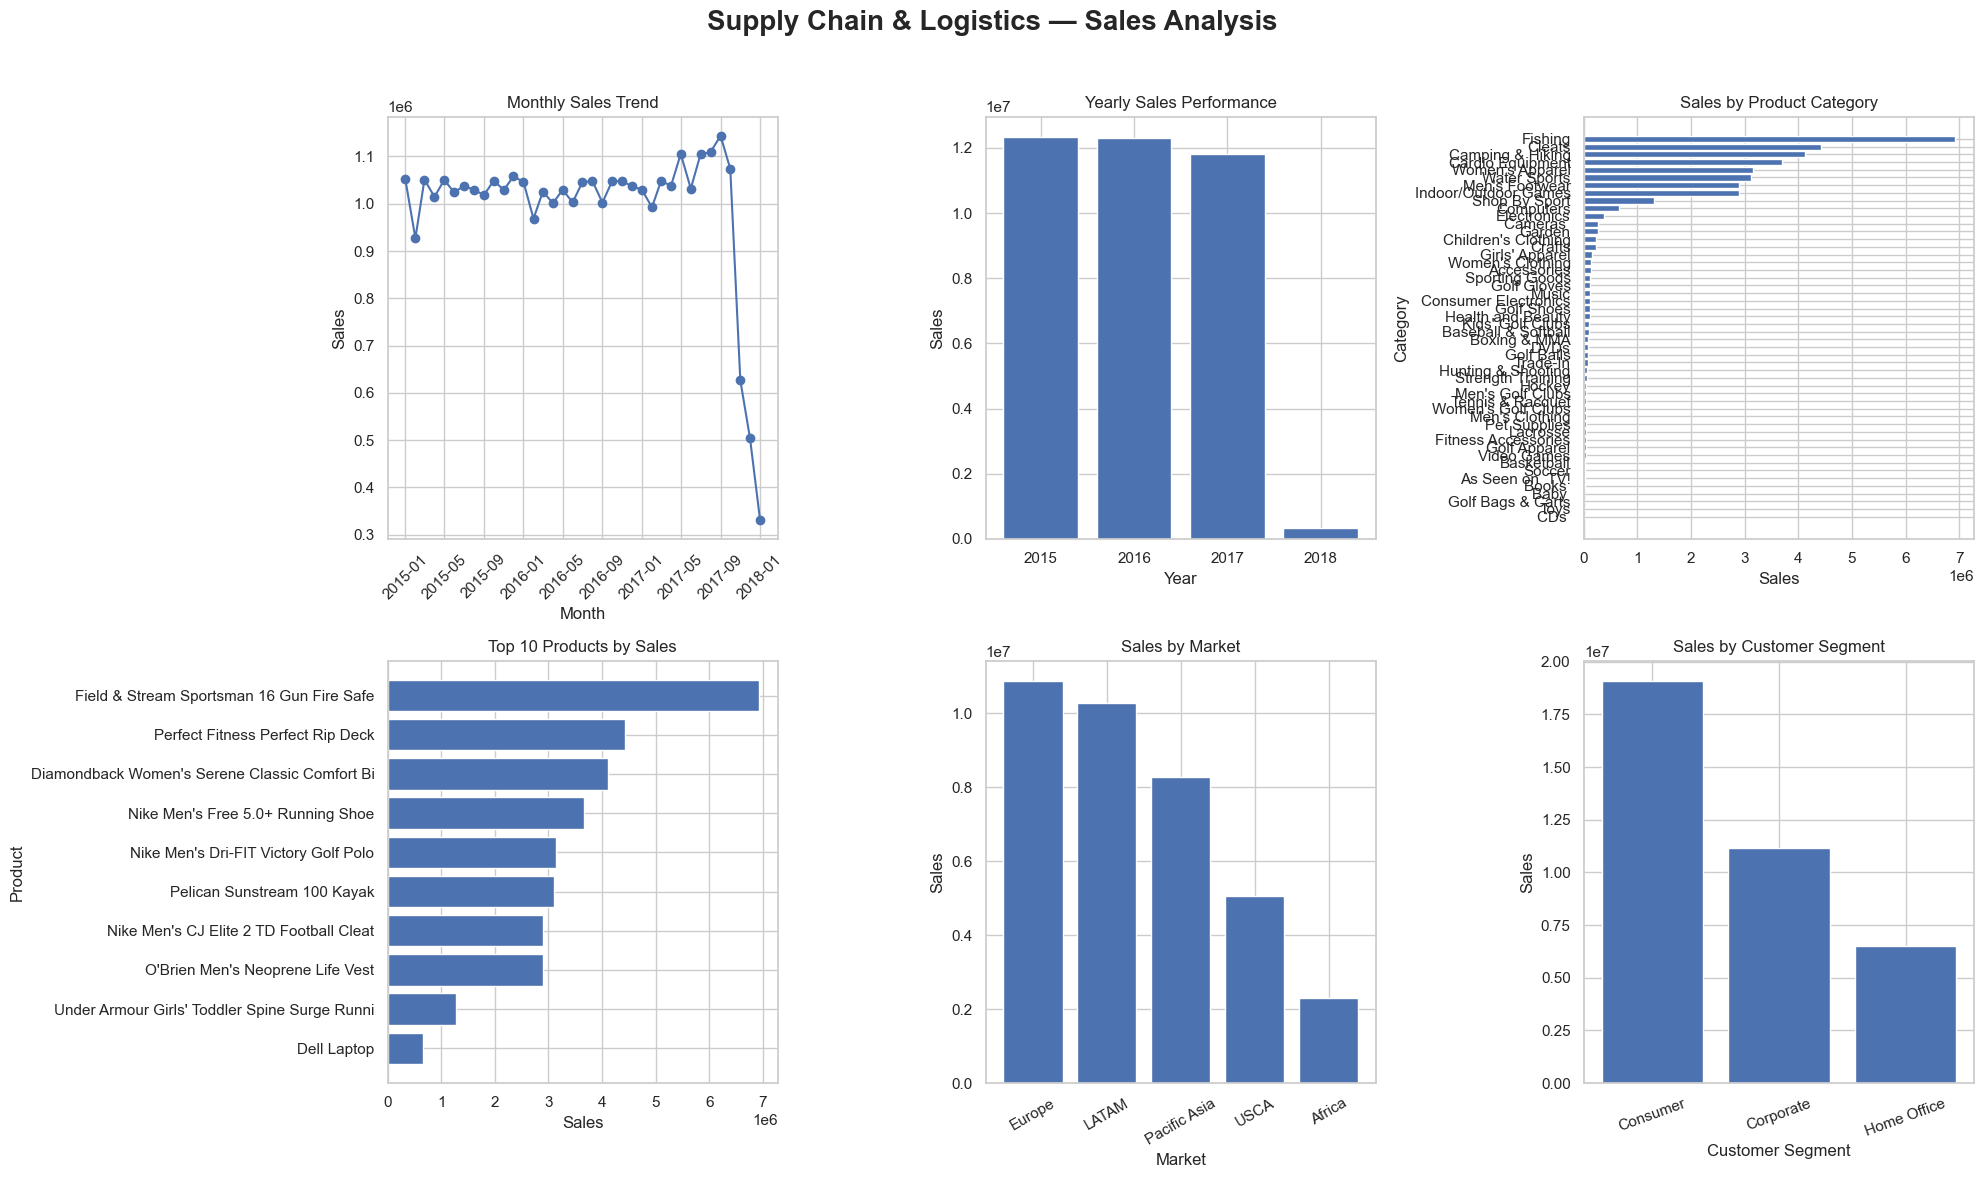

Saved successfully: ..\images\sales_analysis.png


In [56]:
# ============================================================
# SAVE SALES ANALYSIS IMAGE
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

# Create images directory
IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

# Create presentation figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ------------------------------------------------------------
# 1. Monthly Sales Trend
# ------------------------------------------------------------

axes[0, 0].plot(
    monthly_sales["Year_Month"],
    monthly_sales["Sales"],
    marker="o"
)

axes[0, 0].set_title("Monthly Sales Trend")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Sales")
axes[0, 0].tick_params(axis="x", rotation=45)

# ------------------------------------------------------------
# 2. Yearly Sales
# ------------------------------------------------------------

axes[0, 1].bar(
    yearly_sales["Order_Year"].astype(str),
    yearly_sales["Sales"]
)

axes[0, 1].set_title("Yearly Sales Performance")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Sales")

# ------------------------------------------------------------
# 3. Sales by Category
# ------------------------------------------------------------

category_plot = category_sales.sort_values("Sales")

axes[0, 2].barh(
    category_plot["Category Name"],
    category_plot["Sales"]
)

axes[0, 2].set_title("Sales by Product Category")
axes[0, 2].set_xlabel("Sales")
axes[0, 2].set_ylabel("Category")

# ------------------------------------------------------------
# 4. Top 10 Products
# ------------------------------------------------------------

product_plot = top_products.sort_values("Sales")

axes[1, 0].barh(
    product_plot["Product Name"],
    product_plot["Sales"]
)

axes[1, 0].set_title("Top 10 Products by Sales")
axes[1, 0].set_xlabel("Sales")
axes[1, 0].set_ylabel("Product")

# ------------------------------------------------------------
# 5. Sales by Market
# ------------------------------------------------------------

axes[1, 1].bar(
    market_sales["Market"],
    market_sales["Sales"]
)

axes[1, 1].set_title("Sales by Market")
axes[1, 1].set_xlabel("Market")
axes[1, 1].set_ylabel("Sales")
axes[1, 1].tick_params(axis="x", rotation=30)

# ------------------------------------------------------------
# 6. Sales by Customer Segment
# ------------------------------------------------------------

axes[1, 2].bar(
    segment_sales["Customer Segment"],
    segment_sales["Sales"]
)

axes[1, 2].set_title("Sales by Customer Segment")
axes[1, 2].set_xlabel("Customer Segment")
axes[1, 2].set_ylabel("Sales")
axes[1, 2].tick_params(axis="x", rotation=20)

# ------------------------------------------------------------
# Main Title
# ------------------------------------------------------------

fig.suptitle(
    "Supply Chain & Logistics — Sales Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save image
sales_image_path = IMAGES_PATH / "sales_analysis.png"

plt.savefig(
    sales_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved successfully: {sales_image_path}")

### Business Insights

The following insights were identified from the sales and revenue analysis:

- The highest-performing category generated the largest share of overall sales.
- Sales showed noticeable variation across different months and years.
- A small group of products contributed a significant portion of total revenue.
- Some regions generated substantially higher sales than others.
- Customer segments showed different levels of revenue contribution.

## 5. Profitability & Discount Analysis

This section evaluates the profitability of the supply chain business across products, categories, markets, and regions.

The analysis also examines the relationship between discounts, sales, and profitability to identify areas where revenue growth may not translate into strong profit performance.

In [57]:
# ============================================================
# PROFITABILITY KPIs
# ============================================================

total_profit = df_clean["Profit"].sum()
average_profit = df_clean["Profit"].mean()
overall_profit_margin = (
    total_profit / df_clean["Sales"].sum()
) * 100

print(f"Total Profit          : ${total_profit:,.2f}")
print(f"Average Profit        : ${average_profit:,.2f}")
print(f"Overall Profit Margin : {overall_profit_margin:.2f}%")

Total Profit          : $4,418,272.19
Average Profit        : $24.48
Overall Profit Margin : 12.01%


In [58]:
# ============================================================
# PROFIT BY CATEGORY
# ============================================================

category_profit = (
    df_clean
    .groupby("Category Name", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

category_profit["Profit_Margin_%"] = (
    category_profit["Profit"]
    / category_profit["Sales"]
    * 100
)

category_profit = category_profit.sort_values(
    "Profit",
    ascending=False
)

category_profit

,Category Name,Sales,Profit,Profit_Margin_%
18,Fishing,6.929654e+06,841601.940678,12.144935
12,Cleats,4.431943e+06,551017.891083,12.432875
9,Camping & Hiking,4.118426e+06,477520.181090,11.594727
10,Cardio Equipment,3.694843e+06,429254.106047,11.617654
47,Women's Apparel,3.147800e+06,388652.000097,12.346782
46,Water Sports,3.113845e+06,362520.407762,11.642212
30,Indoor/Outdoor Games,2.888994e+06,353791.923211,12.246198
34,Men's Footwear,2.891758e+06,347367.092045,12.012317
38,Shop By Sport,1.309522e+06,144585.760726,11.041109
13,Computers,6.630000e+05,77610.000210,11.705882


In [59]:
fig = px.bar(
    category_profit,
    x="Profit",
    y="Category Name",
    orientation="h",
    text_auto=".2s",
    title="Profit by Product Category"
)

fig.update_layout(
    xaxis_title="Total Profit",
    yaxis_title="Category"
)

fig.show()

In [60]:
fig = px.bar(
    category_profit.sort_values("Profit_Margin_%"),
    x="Profit_Margin_%",
    y="Category Name",
    orientation="h",
    text_auto=".2f",
    title="Profit Margin by Product Category"
)

fig.update_layout(
    xaxis_title="Profit Margin (%)",
    yaxis_title="Category"
)

fig.show()

In [61]:
# ============================================================
# PROFIT BY MARKET
# ============================================================

market_profit = (
    df_clean
    .groupby("Market", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

market_profit["Profit_Margin_%"] = (
    market_profit["Profit"]
    / market_profit["Sales"]
    * 100
)

market_profit = market_profit.sort_values(
    "Profit",
    ascending=False
)

market_profit

,Market,Sales,Profit,Profit_Margin_%
1,Europe,1.087240e+07,1.301774e+06,11.973204
2,LATAM,1.027761e+07,1.253631e+06,12.197684
3,Pacific Asia,8.273744e+06,9.533373e+05,11.522442
4,USCA,5.066529e+06,6.292306e+05,12.419363
0,Africa,2.294453e+06,2.802992e+05,12.216386


In [62]:
fig = px.bar(
    market_profit,
    x="Market",
    y="Profit",
    text_auto=".2s",
    title="Profit by Market"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Total Profit"
)

fig.show()

In [63]:
# ============================================================
# PROFIT BY REGION
# ============================================================

region_profit = (
    df_clean
    .groupby("Order Region", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

region_profit["Profit_Margin_%"] = (
    region_profit["Profit"]
    / region_profit["Sales"]
    * 100
)

region_profit = region_profit.sort_values(
    "Profit",
    ascending=False
)

region_profit.head(15)

,Order Region,Sales,Profit,Profit_Margin_%
22,Western Europe,5.894381e+06,697490.650215,11.833145
3,Central America,5.665712e+06,687554.460816,12.135358
12,South America,2.960881e+06,374434.439454,12.646046
10,Northern Europe,2.155831e+06,258808.320629,12.005039
17,Southern Europe,2.047919e+06,257084.000555,12.553427
15,Southeast Asia,1.932496e+06,235011.493578,12.161037
11,Oceania,2.016654e+06,223548.638582,11.085125
1,Caribbean,1.651019e+06,191641.879513,11.607489
13,South Asia,1.553681e+06,184468.873374,11.873022
21,West of USA,1.571416e+06,183365.456936,11.668805


In [64]:
fig = px.bar(
    region_profit.head(15).sort_values("Profit"),
    x="Profit",
    y="Order Region",
    orientation="h",
    text_auto=".2s",
    title="Top 15 Regions by Profit"
)

fig.update_layout(
    xaxis_title="Total Profit",
    yaxis_title="Region"
)

fig.show()

In [65]:
# ============================================================
# TOP 10 PRODUCTS BY PROFIT
# ============================================================

top_profit_products = (
    df_clean
    .groupby("Product Name", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_profit_products

,Product Name,Sales,Profit
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,841601.940678
71,Perfect Fitness Perfect Rip Deck,4.421143e+06,550057.923096
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,477520.181090
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,425888.406059
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,388652.000097
70,Pelican Sunstream 100 Kayak,3.099845e+06,361361.940889
67,O'Brien Men's Neoprene Life Vest,2.888994e+06,353791.923211
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,347367.092045
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,140687.221497
18,Dell Laptop,6.630000e+05,77610.000210


In [66]:
fig = px.bar(
    top_profit_products.sort_values("Profit"),
    x="Profit",
    y="Product Name",
    orientation="h",
    text_auto=".2s",
    title="Top 10 Products by Profit"
)

fig.update_layout(
    xaxis_title="Total Profit",
    yaxis_title="Product"
)

fig.show()

In [67]:
# ============================================================
# BOTTOM 10 PRODUCTS BY PROFIT
# ============================================================

bottom_profit_products = (
    df_clean
    .groupby("Product Name", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Profit", ascending=True)
    .head(10)
)

bottom_profit_products

,Product Name,Sales,Profit
77,SOLE E35 Elliptical,29999.849850,-899.995529
76,SOLE E25 Elliptical,9999.899902,-359.996336
9,Bushnell Pro X7 Jolt Slope Rangefinder,6599.889892,-161.997282
36,GoPro HERO3+ Black Edition Camera,12799.679686,191.995213
20,Diamondback Girls' Clarity 24 Hybrid Bike 201,8399.719726,317.989402
73,Polar Loop Activity Tracker,5937.299833,356.238002
10,CDs of rock,3059.589989,415.810700
13,Cleveland Golf Women's 588 RTX CB Satin Chrom,8399.299853,437.963472
80,Stiga Master Series ST3100 Competition Indoor,8909.729735,438.886701
30,Garmin Forerunner 910XT GPS Watch,13999.649657,539.986475


In [68]:
fig = px.bar(
    bottom_profit_products.sort_values("Profit"),
    x="Profit",
    y="Product Name",
    orientation="h",
    text_auto=".2s",
    title="Bottom 10 Products by Profit"
)

fig.update_layout(
    xaxis_title="Total Profit",
    yaxis_title="Product"
)

fig.show()

In [69]:
# ============================================================
# DISCOUNT ANALYSIS
# ============================================================

discount_summary = (
    df_clean["Order Item Discount Rate"]
    .describe()
)

discount_summary

count    180519.000000
mean          0.101668
std           0.070415
min           0.000000
25%           0.040000
50%           0.100000
75%           0.160000
max           0.250000
Name: Order Item Discount Rate, dtype: float64

In [70]:
# ============================================================
# CREATE DISCOUNT BANDS
# ============================================================

df_clean["Discount_Band"] = pd.cut(
    df_clean["Order Item Discount Rate"],
    bins=[-0.01, 0.10, 0.20, 0.30, 0.40, 1.00],
    labels=[
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40%+"
    ]
)

df_clean["Discount_Band"].value_counts().sort_index()

Discount_Band
0-10%     90258
10-20%    70203
20-30%    20058
30-40%        0
40%+          0
Name: count, dtype: int64

In [71]:
# ============================================================
# DISCOUNT BAND PERFORMANCE
# ============================================================

discount_profit = (
    df_clean
    .groupby("Discount_Band", observed=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Average_Profit_Margin=("Profit_Margin", "mean")
    )
    .reset_index()
)

discount_profit

,Discount_Band,Sales,Profit,Average_Profit_Margin
0,0-10%,1.838847e+07,2.237930e+06,12.264331
1,10-20%,1.430770e+07,1.702022e+06,11.834323
2,20-30%,4.088565e+06,4.783209e+05,11.972380
3,30-40%,0.000000e+00,0.000000e+00,NaN
4,40%+,0.000000e+00,0.000000e+00,NaN


In [72]:
fig = px.bar(
    discount_profit,
    x="Discount_Band",
    y="Profit",
    text_auto=".2s",
    title="Profit by Discount Band"
)

fig.update_layout(
    xaxis_title="Discount Band",
    yaxis_title="Total Profit"
)

fig.show()

In [73]:
# ============================================================
# SALES VS PROFIT
# ============================================================

product_performance = (
    df_clean
    .groupby("Product Name", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

product_performance["Profit_Margin_%"] = (
    product_performance["Profit"]
    / product_performance["Sales"]
    * 100
)

product_performance.head()

,Product Name,Sales,Profit,Profit_Margin_%
0,Adult dog supplies,41524.800753,3907.720068,9.410569
1,Baby sweater,12229.560379,1705.048863,13.942029
2,Bag Boy Beverage Holder,21116.549776,3495.101356,16.551479
3,Bag Boy M330 Push Cart,16637.919929,3333.183323,20.033654
4,Bowflex SelectTech 1090 Dumbbells,5999.899902,1397.976649,23.300000


In [74]:
# ============================================================
# 5.11 SALES VS PROFIT BY PRODUCT
# ============================================================

# Create a clean copy only for visualization
plot_data = product_performance.copy()

# Convert required columns to numeric
plot_data["Sales"] = pd.to_numeric(
    plot_data["Sales"],
    errors="coerce"
)

plot_data["Profit"] = pd.to_numeric(
    plot_data["Profit"],
    errors="coerce"
)

plot_data["Profit_Margin_%"] = pd.to_numeric(
    plot_data["Profit_Margin_%"],
    errors="coerce"
)

# Remove missing and infinite values
plot_data = plot_data.dropna(
    subset=[
        "Sales",
        "Profit",
        "Profit_Margin_%",
        "Product Name"
    ]
)

plot_data = plot_data[
    np.isfinite(plot_data["Sales"])
    & np.isfinite(plot_data["Profit"])
    & np.isfinite(plot_data["Profit_Margin_%"])
]

# Create scatter plot
fig = px.scatter(
    plot_data,
    x="Sales",
    y="Profit",
    hover_name="Product Name",
    hover_data={
        "Sales": ":,.2f",
        "Profit": ":,.2f",
        "Profit_Margin_%": ":.2f"
    },
    title="Sales vs Profit by Product"
)

fig.update_layout(
    xaxis_title="Total Sales",
    yaxis_title="Total Profit"
)

fig.show()

In [75]:
# ============================================================
# 5.12 HIGH SALES / LOW PROFIT PRODUCTS
# ============================================================

sales_median = product_performance["Sales"].median()
profit_median = product_performance["Profit"].median()

high_sales_low_profit = product_performance[
    (product_performance["Sales"] >= sales_median)
    &
    (product_performance["Profit"] < profit_median)
].copy()

high_sales_low_profit = high_sales_low_profit.sort_values(
    "Sales",
    ascending=False
)

print(
    f"Sales median : ${sales_median:,.2f}"
)

print(
    f"Profit median: ${profit_median:,.2f}"
)

print(
    f"\nHigh-sales / low-profit products found: "
    f"{len(high_sales_low_profit)}"
)

high_sales_low_profit.head(10)

Sales median : $20,582.35
Profit median: $2,675.00

High-sales / low-profit products found: 9


,Product Name,Sales,Profit,Profit_Margin_%
48,Men's gala suit,43856.801269,2323.567063,5.298077
77,SOLE E35 Elliptical,29999.849850,-899.995529,-3.000000
22,ENO Atlas Hammock Straps,29930.019742,2390.502903,7.986974
6,Bridgestone e6 Straight Distance NFL San Dieg,28982.939821,2336.869461,8.062914
107,Under Armour Women's Ignite PIP VI Slide,27127.519792,2236.420854,8.244104
7,Bridgestone e6 Straight Distance NFL Tennesse,25751.949756,2654.530189,10.308075
90,Team Golf Tennessee Volunteers Putter Grip,22865.849747,2618.202282,11.450273
50,Merrell Women's Grassbow Sport Hiking Shoe,20697.929992,1915.808387,9.256039
62,Nike Men's Free TR 5.0 TB Training Shoe,20597.939964,739.925982,3.592233


In [76]:
# ============================================================
# 5.13 PROFITABILITY SUMMARY
# ============================================================

total_sales_value = df_clean["Sales"].sum()
total_profit_value = df_clean["Profit"].sum()

overall_profit_margin_value = (
    total_profit_value / total_sales_value * 100
    if total_sales_value != 0
    else 0
)

average_profit_value = df_clean["Profit"].mean()

profitability_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Overall Profit Margin",
        "Average Profit per Record"
    ],
    "Value": [
        total_sales_value,
        total_profit_value,
        overall_profit_margin_value,
        average_profit_value
    ]
})

profitability_summary

,Metric,Value
0,Total Sales,3.678474e+07
1,Total Profit,4.418272e+06
2,Overall Profit Margin,1.201116e+01
3,Average Profit per Record,2.447539e+01


### Business Insights

The following insights were identified from the profitability and discount analysis:

- The business generated approximately $36.78 million in total sales and $4.42 million in total profit.
- The overall profit margin was approximately 12.01%, indicating a positive but moderate profitability level.
- Profitability varies across product categories, markets, and regions, highlighting differences in business performance.
- Discount levels have an impact on profitability, making discount optimization important for maintaining healthy margins.
- High-sales but low-profit products should be reviewed for pricing, discount, and cost optimization opportunities.

## 6. Logistics & Delivery Performance

This section evaluates logistics and delivery performance across shipping modes, markets, regions, and order statuses.

The analysis focuses on delivery delays, scheduled versus actual shipping times, delivery performance, and operational efficiency to identify potential logistics improvement areas.

In [77]:
# ============================================================
# LOGISTICS KPIs
# ============================================================

total_orders = len(df_clean)

average_actual_shipping_days = (
    df_clean["Days for shipping (real)"].mean()
)

average_scheduled_shipping_days = (
    df_clean["Days for shipment (scheduled)"].mean()
)

average_delivery_delay = (
    df_clean["Delivery_Delay_Days"].mean()
)

delayed_orders = (
    df_clean["Delivery_Performance"]
    .eq("Delayed")
    .sum()
)

on_time_orders = (
    df_clean["Delivery_Performance"]
    .eq("On Time")
    .sum()
)

early_orders = (
    df_clean["Delivery_Performance"]
    .eq("Early")
    .sum()
)

print(f"Total Orders                  : {total_orders:,}")
print(
    f"Average Actual Shipping Days : "
    f"{average_actual_shipping_days:.2f}"
)
print(
    f"Average Scheduled Days       : "
    f"{average_scheduled_shipping_days:.2f}"
)
print(
    f"Average Delivery Delay       : "
    f"{average_delivery_delay:.2f} days"
)
print(f"Delayed Orders               : {delayed_orders:,}")
print(f"On-Time Orders               : {on_time_orders:,}")
print(f"Early Orders                 : {early_orders:,}")

Total Orders                  : 180,519
Average Actual Shipping Days : 3.50
Average Scheduled Days       : 2.93
Average Delivery Delay       : 0.57 days
Delayed Orders               : 103,400
On-Time Orders               : 33,753
Early Orders                 : 43,366


In [78]:
# ============================================================
#  DELIVERY PERFORMANCE DISTRIBUTION
# ============================================================

delivery_performance = (
    df_clean["Delivery_Performance"]
    .value_counts()
    .reset_index()
)

delivery_performance.columns = [
    "Delivery_Performance",
    "Orders"
]

delivery_performance["Percentage"] = (
    delivery_performance["Orders"]
    / delivery_performance["Orders"].sum()
    * 100
)

delivery_performance

,Delivery_Performance,Orders,Percentage
0,Delayed,103400,57.279289
1,Early,43366,24.022956
2,On Time,33753,18.697755


In [79]:
fig = px.bar(
    delivery_performance,
    x="Delivery_Performance",
    y="Orders",
    text_auto=True,
    title="Delivery Performance Distribution"
)

fig.update_layout(
    xaxis_title="Delivery Performance",
    yaxis_title="Number of Orders"
)

fig.show()

In [80]:
# ============================================================
# 6.4 DELIVERY DELAY DISTRIBUTION
# ============================================================

delay_summary = df_clean["Delivery_Delay_Days"].describe()

delay_summary

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delivery_Delay_Days, dtype: float64

In [81]:
fig = px.histogram(
    df_clean,
    x="Delivery_Delay_Days",
    nbins=30,
    title="Distribution of Delivery Delays"
)

fig.update_layout(
    xaxis_title="Delivery Delay (Days)",
    yaxis_title="Number of Orders"
)

fig.show()

In [82]:
# ============================================================
# 6.5 SHIPPING MODE PERFORMANCE
# ============================================================

shipping_performance = (
    df_clean
    .groupby("Shipping Mode", as_index=False)
    .agg(
        Orders=("Shipping Mode", "size"),
        Average_Delay=("Delivery_Delay_Days", "mean"),
        Average_Actual_Days=("Days for shipping (real)", "mean"),
        Average_Scheduled_Days=(
            "Days for shipment (scheduled)",
            "mean"
        )
    )
)

shipping_performance

,Shipping Mode,Orders,Average_Delay,Average_Actual_Days,Average_Scheduled_Days
0,First Class,27814,1.000000,2.000000,1.0
1,Same Day,9737,0.478279,0.478279,0.0
2,Second Class,35216,1.990828,3.990828,2.0
3,Standard Class,107752,-0.004093,3.995907,4.0


In [83]:
fig = px.bar(
    shipping_performance.sort_values("Average_Delay"),
    x="Shipping Mode",
    y="Average_Delay",
    text_auto=".2f",
    title="Average Delivery Delay by Shipping Mode"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Average Delay (Days)"
)

fig.show()

In [84]:
# ============================================================
# 6.6 SHIPPING MODE VS DELIVERY PERFORMANCE
# ============================================================

shipping_delivery = (
    df_clean
    .groupby(
        ["Shipping Mode", "Delivery_Performance"]
    )
    .size()
    .reset_index(name="Orders")
)

shipping_delivery

,Shipping Mode,Delivery_Performance,Orders
0,First Class,Delayed,27814
1,Same Day,Delayed,4657
2,Same Day,On Time,5080
3,Second Class,Delayed,28078
4,Second Class,On Time,7138
5,Standard Class,Delayed,42851
6,Standard Class,Early,43366
7,Standard Class,On Time,21535


In [85]:
fig = px.bar(
    shipping_delivery,
    x="Shipping Mode",
    y="Orders",
    color="Delivery_Performance",
    barmode="group",
    title="Shipping Mode vs Delivery Performance"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Number of Orders"
)

fig.show()

In [86]:
# ============================================================
# 6.7 DELIVERY PERFORMANCE BY MARKET
# ============================================================

market_delivery = (
    df_clean
    .groupby(
        ["Market", "Delivery_Performance"]
    )
    .size()
    .reset_index(name="Orders")
)

market_delivery

,Market,Delivery_Performance,Orders
0,Africa,Delayed,6598
1,Africa,Early,2754
2,Africa,On Time,2262
3,Europe,Delayed,28989
4,Europe,Early,12073
5,Europe,On Time,9190
6,LATAM,Delayed,29420
7,LATAM,Early,12539
8,LATAM,On Time,9635
9,Pacific Asia,Delayed,23649


In [87]:
fig = px.bar(
    market_delivery,
    x="Market",
    y="Orders",
    color="Delivery_Performance",
    barmode="group",
    title="Delivery Performance by Market"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Number of Orders"
)

fig.show()

In [88]:
# ============================================================
# 6.8 DELIVERY DELAY BY REGION
# ============================================================

region_delay = (
    df_clean
    .groupby("Order Region", as_index=False)
    .agg(
        Orders=("Order Region", "size"),
        Average_Delay=("Delivery_Delay_Days", "mean"),
        Delayed_Orders=(
            "Delivery_Performance",
            lambda x: (x == "Delayed").sum()
        )
    )
)

region_delay["Delayed_%"] = (
    region_delay["Delayed_Orders"]
    / region_delay["Orders"]
    * 100
)

region_delay = region_delay.sort_values(
    "Average_Delay",
    ascending=False
)

region_delay.head(15)

,Order Region,Orders,Average_Delay,Delayed_Orders,Delayed_%
4,Central Asia,553,0.645570,316,57.142857
2,Central Africa,1677,0.639833,1018,60.703637
13,South Asia,7731,0.597465,4523,58.504721
22,Western Europe,27109,0.597403,15863,58.515622
18,US Center,5887,0.587226,3363,57.125871
6,East of USA,6915,0.584816,4009,57.975416
14,South of USA,4045,0.579975,2350,58.096415
8,Eastern Europe,3920,0.579847,2252,57.448980
5,East Africa,1852,0.570734,1064,57.451404
20,West Asia,6009,0.569479,3455,57.497088


In [89]:
fig = px.bar(
    region_delay.head(15).sort_values("Average_Delay"),
    x="Average_Delay",
    y="Order Region",
    orientation="h",
    text_auto=".2f",
    title="Top 15 Regions by Average Delivery Delay"
)

fig.update_layout(
    xaxis_title="Average Delay (Days)",
    yaxis_title="Region"
)

fig.show()

In [90]:
fig = px.bar(
    region_delay.head(15).sort_values("Delayed_%"),
    x="Delayed_%",
    y="Order Region",
    orientation="h",
    text_auto=".2f",
    title="Regions with Highest Delayed Order Percentage"
)

fig.update_layout(
    xaxis_title="Delayed Orders (%)",
    yaxis_title="Region"
)

fig.show()

In [91]:
# ============================================================
# 6.10 ORDER STATUS ANALYSIS
# ============================================================

df_clean["Order Status"].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [92]:
order_status = (
    df_clean["Order Status"]
    .value_counts()
    .reset_index()
)

order_status.columns = [
    "Order_Status",
    "Orders"
]

order_status["Percentage"] = (
    order_status["Orders"]
    / order_status["Orders"].sum()
    * 100
)

order_status

,Order_Status,Orders,Percentage
0,COMPLETE,59491,32.955534
1,PENDING_PAYMENT,39832,22.065267
2,PROCESSING,21902,12.132795
3,PENDING,20227,11.204915
4,CLOSED,19616,10.866446
5,ON_HOLD,9804,5.431007
6,SUSPECTED_FRAUD,4062,2.250179
7,CANCELED,3692,2.045214
8,PAYMENT_REVIEW,1893,1.048643


In [93]:
fig = px.bar(
    order_status,
    x="Order_Status",
    y="Orders",
    text_auto=True,
    title="Order Status Distribution"
)

fig.update_layout(
    xaxis_title="Order Status",
    yaxis_title="Number of Orders"
)

fig.show()

In [94]:
# ============================================================
# 6.11 SCHEDULED VS ACTUAL SHIPPING TIME
# ============================================================

shipping_comparison = pd.DataFrame({
    "Metric": [
        "Scheduled Shipping Days",
        "Actual Shipping Days"
    ],
    "Average_Days": [
        df_clean["Days for shipment (scheduled)"].mean(),
        df_clean["Days for shipping (real)"].mean()
    ]
})

shipping_comparison

,Metric,Average_Days
0,Scheduled Shipping Days,2.931847
1,Actual Shipping Days,3.497654


In [95]:
fig = px.bar(
    shipping_comparison,
    x="Metric",
    y="Average_Days",
    text_auto=".2f",
    title="Scheduled vs Actual Shipping Time"
)

fig.update_layout(
    xaxis_title="Shipping Metric",
    yaxis_title="Average Days"
)

fig.show()

In [96]:
# ============================================================
# 6.12 LOGISTICS SUMMARY
# ============================================================

logistics_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Average Actual Shipping Days",
        "Average Scheduled Shipping Days",
        "Average Delivery Delay",
        "Delayed Orders",
        "On-Time Orders",
        "Early Orders"
    ],
    "Value": [
        total_orders,
        average_actual_shipping_days,
        average_scheduled_shipping_days,
        average_delivery_delay,
        delayed_orders,
        on_time_orders,
        early_orders
    ]
})

logistics_summary

,Metric,Value
0,Total Orders,180519.000000
1,Average Actual Shipping Days,3.497654
2,Average Scheduled Shipping Days,2.931847
3,Average Delivery Delay,0.565807
4,Delayed Orders,103400.000000
5,On-Time Orders,33753.000000
6,Early Orders,43366.000000


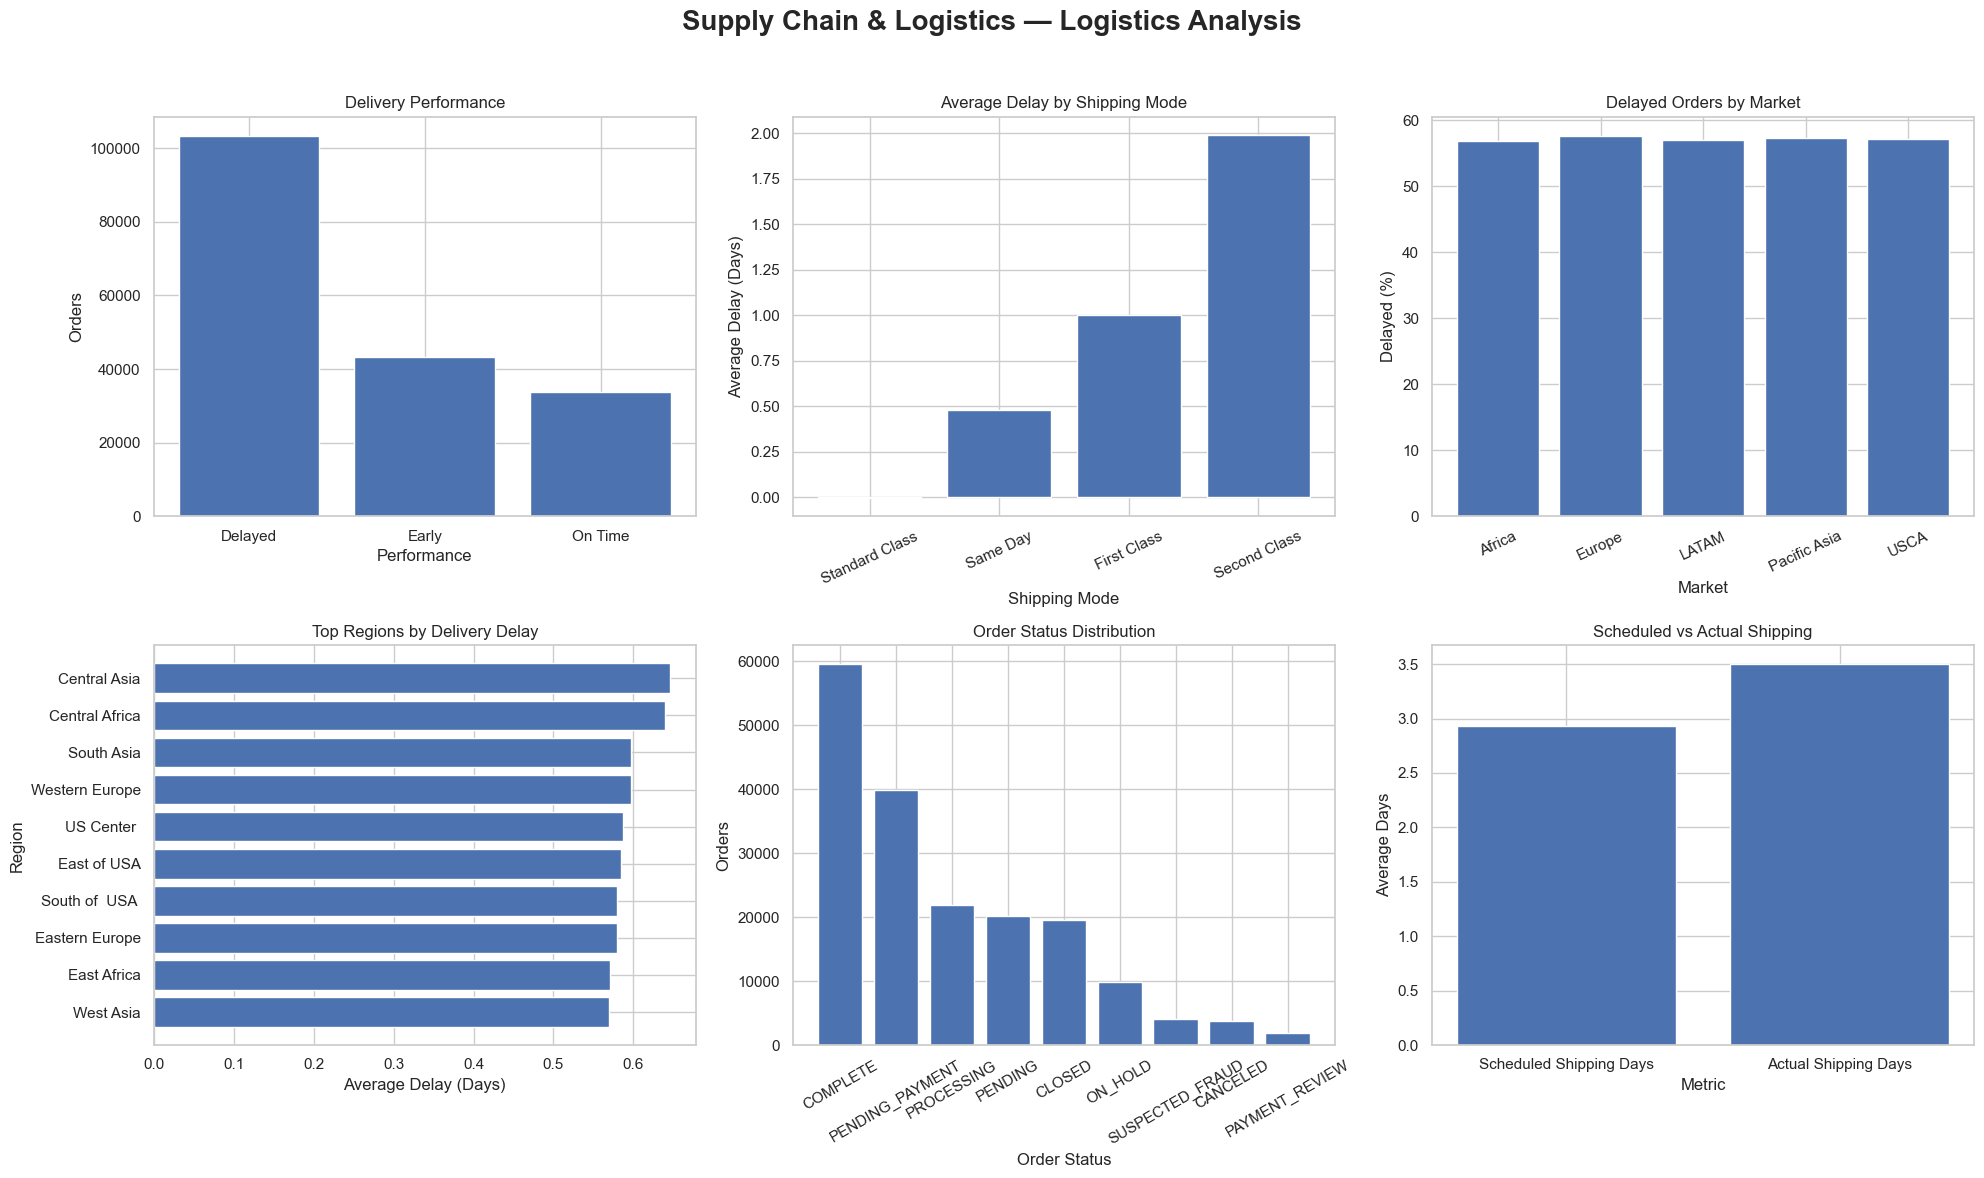

Saved successfully: ..\images\logistics_analysis.png


In [97]:
# ============================================================
# 6.13 SAVE LOGISTICS ANALYSIS IMAGE
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ------------------------------------------------------------
# 1. Delivery Performance
# ------------------------------------------------------------

axes[0, 0].bar(
    delivery_performance["Delivery_Performance"],
    delivery_performance["Orders"]
)

axes[0, 0].set_title("Delivery Performance")
axes[0, 0].set_xlabel("Performance")
axes[0, 0].set_ylabel("Orders")

# ------------------------------------------------------------
# 2. Shipping Mode Delay
# ------------------------------------------------------------

shipping_plot = shipping_performance.sort_values(
    "Average_Delay"
)

axes[0, 1].bar(
    shipping_plot["Shipping Mode"],
    shipping_plot["Average_Delay"]
)

axes[0, 1].set_title("Average Delay by Shipping Mode")
axes[0, 1].set_xlabel("Shipping Mode")
axes[0, 1].set_ylabel("Average Delay (Days)")
axes[0, 1].tick_params(axis="x", rotation=25)

# ------------------------------------------------------------
# 3. Market Delivery Performance
# ------------------------------------------------------------

market_delayed = (
    df_clean
    .groupby("Market")
    .agg(
        Orders=("Market", "size"),
        Delayed_Orders=(
            "Delivery_Performance",
            lambda x: (x == "Delayed").sum()
        )
    )
    .reset_index()
)

market_delayed["Delayed_%"] = (
    market_delayed["Delayed_Orders"]
    / market_delayed["Orders"]
    * 100
)

axes[0, 2].bar(
    market_delayed["Market"],
    market_delayed["Delayed_%"]
)

axes[0, 2].set_title("Delayed Orders by Market")
axes[0, 2].set_xlabel("Market")
axes[0, 2].set_ylabel("Delayed (%)")
axes[0, 2].tick_params(axis="x", rotation=25)

# ------------------------------------------------------------
# 4. Top Regions by Delay
# ------------------------------------------------------------

region_plot = region_delay.head(10).sort_values(
    "Average_Delay"
)

axes[1, 0].barh(
    region_plot["Order Region"],
    region_plot["Average_Delay"]
)

axes[1, 0].set_title("Top Regions by Delivery Delay")
axes[1, 0].set_xlabel("Average Delay (Days)")
axes[1, 0].set_ylabel("Region")

# ------------------------------------------------------------
# 5. Order Status
# ------------------------------------------------------------

axes[1, 1].bar(
    order_status["Order_Status"],
    order_status["Orders"]
)

axes[1, 1].set_title("Order Status Distribution")
axes[1, 1].set_xlabel("Order Status")
axes[1, 1].set_ylabel("Orders")
axes[1, 1].tick_params(axis="x", rotation=30)

# ------------------------------------------------------------
# 6. Scheduled vs Actual
# ------------------------------------------------------------

axes[1, 2].bar(
    shipping_comparison["Metric"],
    shipping_comparison["Average_Days"]
)

axes[1, 2].set_title("Scheduled vs Actual Shipping")
axes[1, 2].set_xlabel("Metric")
axes[1, 2].set_ylabel("Average Days")

# ------------------------------------------------------------
# Main Title
# ------------------------------------------------------------

fig.suptitle(
    "Supply Chain & Logistics — Logistics Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

logistics_image_path = (
    IMAGES_PATH / "logistics_analysis.png"
)

plt.savefig(
    logistics_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved successfully: {logistics_image_path}"
)

### Business Insights

The following insights were identified from the logistics and delivery performance analysis:

- Delivery performance analysis helps identify the proportion of orders delivered early, on time, and with delays.
- Differences in average delivery delays across shipping modes highlight opportunities to improve logistics efficiency.
- Certain markets and regions show higher delivery delays and require closer monitoring of logistics operations.
- Comparing scheduled and actual shipping times helps identify gaps between planned and real delivery performance.
- Regions with a high percentage of delayed orders should be prioritized for route, carrier, and delivery process optimization.

## 7. Product & Category Performance Analysis

This section evaluates product-level and category-level performance using sales, quantity, profit, and profit margin metrics.

The objective is to identify high-performing products, underperforming products, profitable categories, and potential areas for product and inventory optimization.

In [98]:
# ============================================================
# 7.2 PRODUCT PERFORMANCE DATASET
# ============================================================

product_analysis = (
    df_clean
    .groupby("Product Name", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Units_Sold=("Order Item Quantity", "sum"),
        Profit=("Profit", "sum")
    )
)

product_analysis["Profit_Margin_%"] = np.where(
    product_analysis["Sales"] != 0,
    (product_analysis["Profit"]
     / product_analysis["Sales"]) * 100,
    0
)

product_analysis = product_analysis.sort_values(
    "Sales",
    ascending=False
)

product_analysis.head(10)

,Product Name,Sales,Units_Sold,Profit,Profit_Margin_%
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,17325,841601.940678,12.144935
71,Perfect Fitness Perfect Rip Deck,4.421143e+06,73698,550057.923096,12.441532
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,13729,477520.181090,11.594727
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,36680,425888.406059,11.612077
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,62956,388652.000097,12.346782
70,Pelican Sunstream 100 Kayak,3.099845e+06,15500,361361.940889,11.657419
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,22246,347367.092045,12.012317
67,O'Brien Men's Neoprene Life Vest,2.888994e+06,57803,353791.923211,12.246198
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,31735,140687.221497,11.085741
18,Dell Laptop,6.630000e+05,442,77610.000210,11.705882


In [99]:
# ============================================================
# 7.3 TOP 10 PRODUCTS BY SALES
# ============================================================

top_sales_products = (
    product_analysis
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_sales_products

,Product Name,Sales,Units_Sold,Profit,Profit_Margin_%
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,17325,841601.940678,12.144935
71,Perfect Fitness Perfect Rip Deck,4.421143e+06,73698,550057.923096,12.441532
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,13729,477520.181090,11.594727
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,36680,425888.406059,11.612077
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,62956,388652.000097,12.346782
70,Pelican Sunstream 100 Kayak,3.099845e+06,15500,361361.940889,11.657419
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,22246,347367.092045,12.012317
67,O'Brien Men's Neoprene Life Vest,2.888994e+06,57803,353791.923211,12.246198
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,31735,140687.221497,11.085741
18,Dell Laptop,6.630000e+05,442,77610.000210,11.705882


In [100]:
fig = px.bar(
    top_sales_products.sort_values("Sales"),
    x="Sales",
    y="Product Name",
    orientation="h",
    text_auto=".2s",
    title="Top 10 Products by Sales"
)

fig.update_layout(
    xaxis_title="Total Sales",
    yaxis_title="Product"
)

fig.show()

In [101]:
# ============================================================
# 7.4 TOP 10 PRODUCTS BY UNITS SOLD
# ============================================================

top_quantity_products = (
    product_analysis
    .sort_values("Units_Sold", ascending=False)
    .head(10)
)

top_quantity_products

,Product Name,Sales,Units_Sold,Profit,Profit_Margin_%
71,Perfect Fitness Perfect Rip Deck,4.421143e+06,73698,550057.923096,12.441532
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,62956,388652.000097,12.346782
67,O'Brien Men's Neoprene Life Vest,2.888994e+06,57803,353791.923211,12.246198
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,36680,425888.406059,11.612077
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,31735,140687.221497,11.085741
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,22246,347367.092045,12.012317
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,17325,841601.940678,12.144935
70,Pelican Sunstream 100 Kayak,3.099845e+06,15500,361361.940889,11.657419
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,13729,477520.181090,11.594727
22,ENO Atlas Hammock Straps,2.993002e+04,998,2390.502903,7.986974


In [102]:
fig = px.bar(
    top_quantity_products.sort_values("Units_Sold"),
    x="Units_Sold",
    y="Product Name",
    orientation="h",
    text_auto=True,
    title="Top 10 Products by Units Sold"
)

fig.update_layout(
    xaxis_title="Units Sold",
    yaxis_title="Product"
)

fig.show()

In [103]:
# ============================================================
# 7.5 TOP 10 PRODUCTS BY PROFIT
# ============================================================

top_profit_products = (
    product_analysis
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_profit_products

,Product Name,Sales,Units_Sold,Profit,Profit_Margin_%
24,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,17325,841601.940678,12.144935
71,Perfect Fitness Perfect Rip Deck,4.421143e+06,73698,550057.923096,12.441532
21,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,13729,477520.181090,11.594727
61,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,36680,425888.406059,11.612077
59,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,62956,388652.000097,12.346782
70,Pelican Sunstream 100 Kayak,3.099845e+06,15500,361361.940889,11.657419
67,O'Brien Men's Neoprene Life Vest,2.888994e+06,57803,353791.923211,12.246198
56,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,22246,347367.092045,12.012317
102,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,31735,140687.221497,11.085741
18,Dell Laptop,6.630000e+05,442,77610.000210,11.705882


In [104]:
fig = px.bar(
    top_profit_products.sort_values("Profit"),
    x="Profit",
    y="Product Name",
    orientation="h",
    text_auto=".2s",
    title="Top 10 Products by Profit"
)

fig.update_layout(
    xaxis_title="Total Profit",
    yaxis_title="Product"
)

fig.show()

In [105]:
# ============================================================
# 7.6 BOTTOM 10 PRODUCTS BY PROFIT
# ============================================================

bottom_profit_products = (
    product_analysis
    .sort_values("Profit", ascending=True)
    .head(10)
)

bottom_profit_products

,Product Name,Sales,Units_Sold,Profit,Profit_Margin_%
77,SOLE E35 Elliptical,29999.849850,15,-899.995529,-3.000000
76,SOLE E25 Elliptical,9999.899902,10,-359.996336,-3.599999
9,Bushnell Pro X7 Jolt Slope Rangefinder,6599.889892,11,-161.997282,-2.454545
36,GoPro HERO3+ Black Edition Camera,12799.679686,32,191.995213,1.500000
20,Diamondback Girls' Clarity 24 Hybrid Bike 201,8399.719726,28,317.989402,3.785714
73,Polar Loop Activity Tracker,5937.299833,54,356.238002,6.000000
10,CDs of rock,3059.589989,271,415.810700,13.590406
13,Cleveland Golf Women's 588 RTX CB Satin Chrom,8399.299853,70,437.963472,5.214285
80,Stiga Master Series ST3100 Competition Indoor,8909.729735,27,438.886701,4.925926
30,Garmin Forerunner 910XT GPS Watch,13999.649657,35,539.986475,3.857143


In [106]:
fig = px.bar(
    bottom_profit_products.sort_values("Profit"),
    x="Profit",
    y="Product Name",
    orientation="h",
    text_auto=".2s",
    title="Bottom 10 Products by Profit"
)

fig.update_layout(
    xaxis_title="Total Profit",
    yaxis_title="Product"
)

fig.show()

In [107]:
# ============================================================
# 7.7 PRODUCT SALES VS UNITS SOLD
# ============================================================

fig = px.scatter(
    product_analysis,
    x="Units_Sold",
    y="Sales",
    hover_name="Product Name",
    hover_data=[
        "Profit",
        "Profit_Margin_%"
    ],
    title="Product Sales vs Units Sold"
)

fig.update_layout(
    xaxis_title="Units Sold",
    yaxis_title="Total Sales"
)

fig.show()

In [108]:
# ============================================================
# 7.8 CATEGORY PERFORMANCE
# ============================================================

category_analysis = (
    df_clean
    .groupby("Category Name", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Units_Sold=("Order Item Quantity", "sum"),
        Profit=("Profit", "sum"),
        Products=("Product Name", "nunique")
    )
)

category_analysis["Profit_Margin_%"] = np.where(
    category_analysis["Sales"] != 0,
    (category_analysis["Profit"]
     / category_analysis["Sales"]) * 100,
    0
)

category_analysis = category_analysis.sort_values(
    "Sales",
    ascending=False
)

category_analysis

,Category Name,Sales,Units_Sold,Profit,Products,Profit_Margin_%
18,Fishing,6.929654e+06,17325,841601.940678,1,12.144935
12,Cleats,4.431943e+06,73734,551017.891083,2,12.432875
9,Camping & Hiking,4.118426e+06,13729,477520.181090,1,11.594727
10,Cardio Equipment,3.694843e+06,37587,429254.106047,2,11.617654
47,Women's Apparel,3.147800e+06,62956,388652.000097,1,12.346782
46,Water Sports,3.113845e+06,15540,362520.407762,2,11.642212
34,Men's Footwear,2.891758e+06,22246,347367.092045,1,12.012317
30,Indoor/Outdoor Games,2.888994e+06,57803,353791.923211,1,12.246198
38,Shop By Sport,1.309522e+06,32726,144585.760726,3,11.041109
13,Computers,6.630000e+05,442,77610.000210,1,11.705882


In [109]:
fig = px.scatter(
    category_analysis,
    x="Sales",
    y="Profit",
    size="Units_Sold",
    hover_name="Category Name",
    hover_data=[
        "Profit_Margin_%",
        "Products"
    ],
    title="Category Sales vs Profit"
)

fig.update_layout(
    xaxis_title="Total Sales",
    yaxis_title="Total Profit"
)

fig.show()

In [110]:
fig = px.bar(
    category_analysis.sort_values("Profit_Margin_%"),
    x="Profit_Margin_%",
    y="Category Name",
    orientation="h",
    text_auto=".2f",
    title="Category Profit Margin"
)

fig.update_layout(
    xaxis_title="Profit Margin (%)",
    yaxis_title="Category"
)

fig.show()

In [111]:
# ============================================================
# 7.11 PRODUCT PERFORMANCE CLASSIFICATION
# ============================================================

sales_median = product_analysis["Sales"].median()
profit_median = product_analysis["Profit"].median()

product_analysis["Performance"] = np.select(
    [
        (product_analysis["Sales"] >= sales_median) &
        (product_analysis["Profit"] >= profit_median),

        (product_analysis["Sales"] >= sales_median) &
        (product_analysis["Profit"] < profit_median),

        (product_analysis["Sales"] < sales_median) &
        (product_analysis["Profit"] >= profit_median),

        (product_analysis["Sales"] < sales_median) &
        (product_analysis["Profit"] < profit_median)
    ],
    [
        "High Sales / High Profit",
        "High Sales / Low Profit",
        "Low Sales / High Profit",
        "Low Sales / Low Profit"
    ],
    default="Unknown"
)

product_analysis["Performance"].value_counts()

Performance
High Sales / High Profit    50
Low Sales / Low Profit      50
High Sales / Low Profit      9
Low Sales / High Profit      9
Name: count, dtype: int64

In [112]:
performance_distribution = (
    product_analysis["Performance"]
    .value_counts()
    .reset_index()
)

performance_distribution.columns = [
    "Performance",
    "Products"
]

performance_distribution

,Performance,Products
0,High Sales / High Profit,50
1,Low Sales / Low Profit,50
2,High Sales / Low Profit,9
3,Low Sales / High Profit,9


In [113]:
fig = px.bar(
    performance_distribution,
    x="Performance",
    y="Products",
    text_auto=True,
    title="Product Performance Classification"
)

fig.update_layout(
    xaxis_title="Performance Category",
    yaxis_title="Number of Products"
)

fig.show()

In [114]:
# ============================================================
# 7.13 PRODUCT ANALYSIS SUMMARY
# ============================================================

product_summary = pd.DataFrame({
    "Metric": [
        "Total Products",
        "Total Units Sold",
        "Total Sales",
        "Total Profit",
        "Average Product Sales",
        "Average Product Profit"
    ],
    "Value": [
        product_analysis["Product Name"].nunique(),
        product_analysis["Units_Sold"].sum(),
        product_analysis["Sales"].sum(),
        product_analysis["Profit"].sum(),
        product_analysis["Sales"].mean(),
        product_analysis["Profit"].mean()
    ]
})

product_summary

,Metric,Value
0,Total Products,1.180000e+02
1,Total Units Sold,3.840790e+05
2,Total Sales,3.678474e+07
3,Total Profit,4.418272e+06
4,Average Product Sales,3.117350e+05
5,Average Product Profit,3.744298e+04


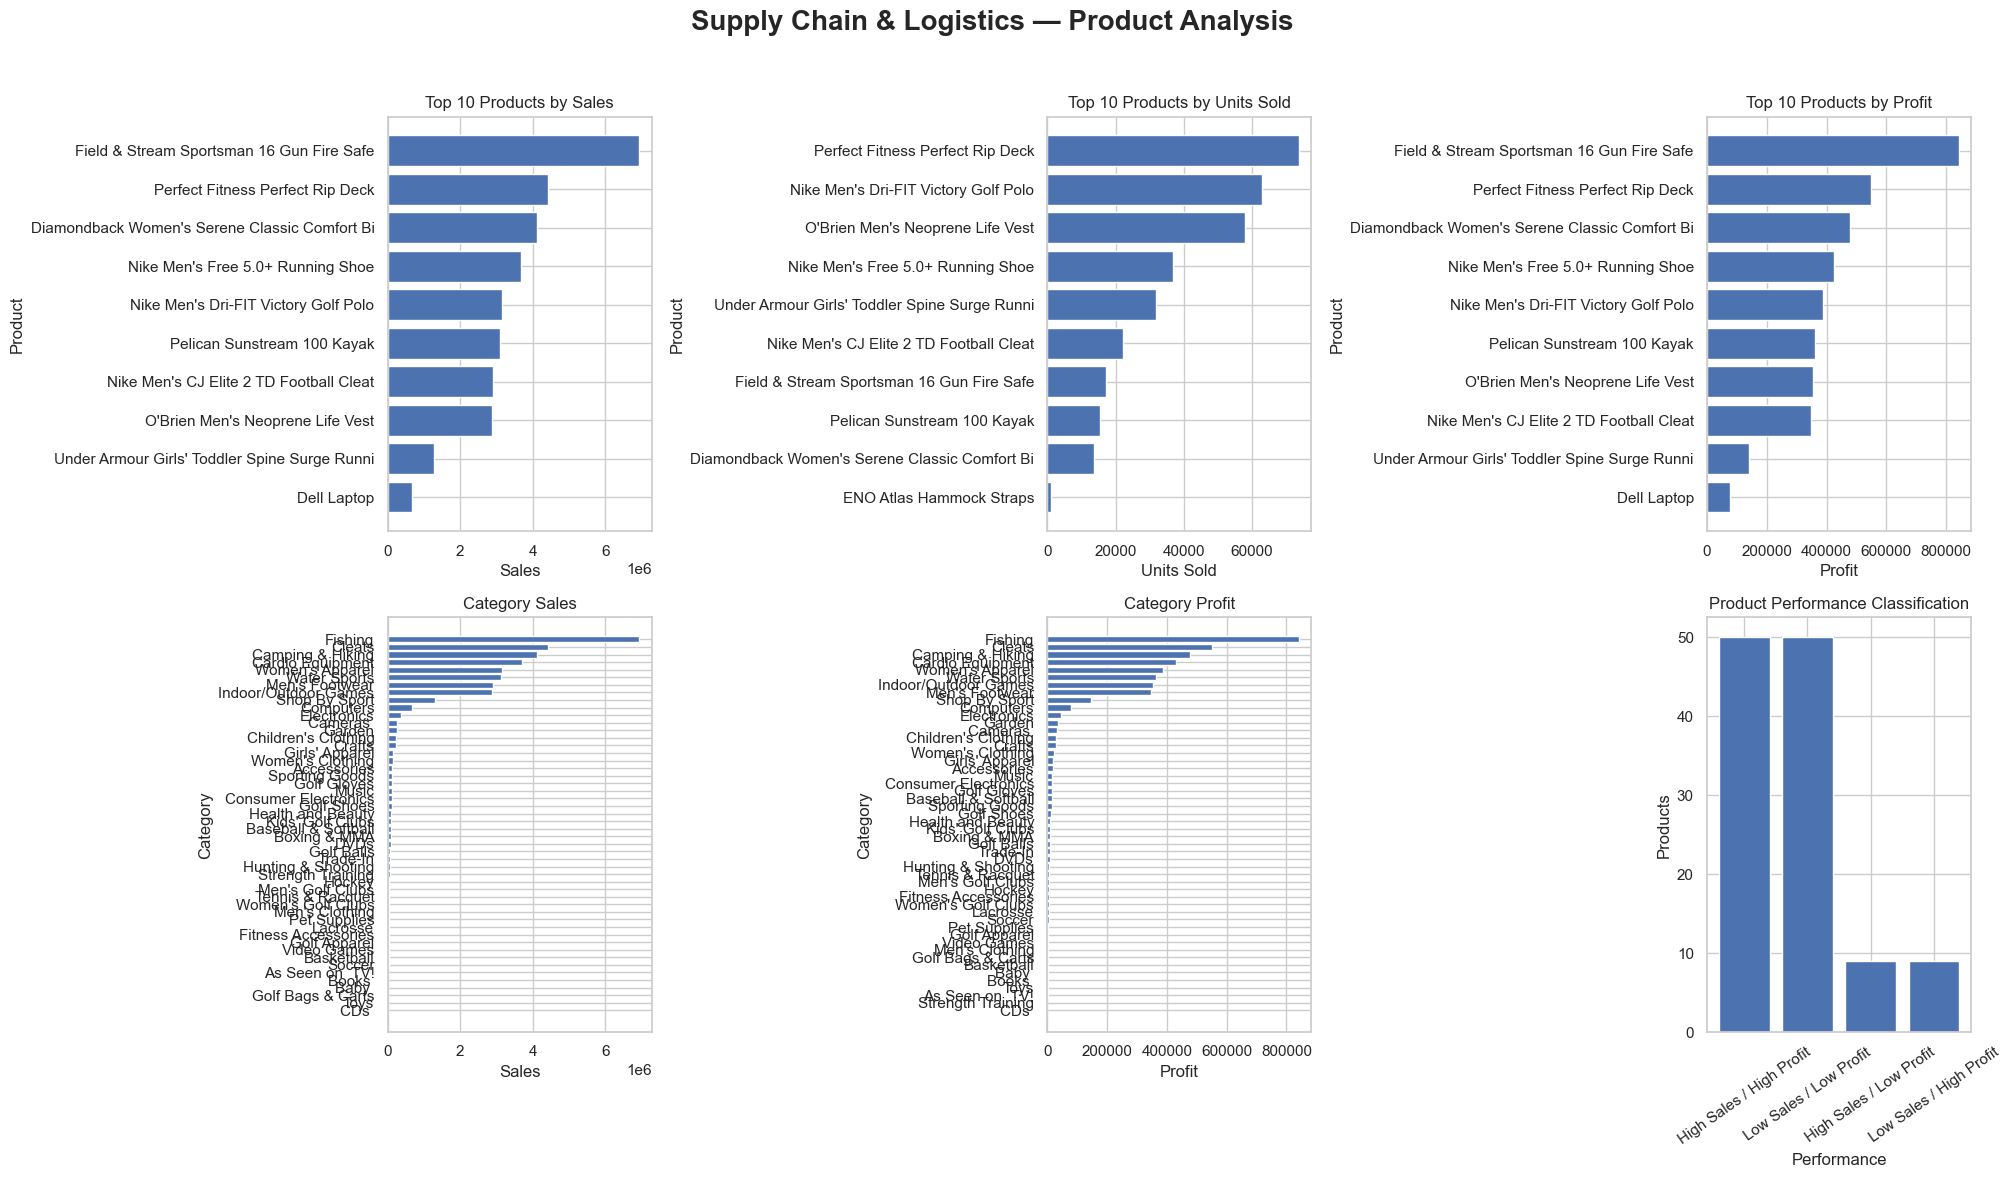

Saved successfully: ..\images\product_analysis.png


In [115]:
# ============================================================
# 7.14 SAVE PRODUCT ANALYSIS IMAGE
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ------------------------------------------------------------
# 1. Top Products by Sales
# ------------------------------------------------------------

sales_plot = top_sales_products.sort_values("Sales")

axes[0, 0].barh(
    sales_plot["Product Name"],
    sales_plot["Sales"]
)

axes[0, 0].set_title("Top 10 Products by Sales")
axes[0, 0].set_xlabel("Sales")
axes[0, 0].set_ylabel("Product")

# ------------------------------------------------------------
# 2. Top Products by Units
# ------------------------------------------------------------

quantity_plot = top_quantity_products.sort_values(
    "Units_Sold"
)

axes[0, 1].barh(
    quantity_plot["Product Name"],
    quantity_plot["Units_Sold"]
)

axes[0, 1].set_title("Top 10 Products by Units Sold")
axes[0, 1].set_xlabel("Units Sold")
axes[0, 1].set_ylabel("Product")

# ------------------------------------------------------------
# 3. Top Products by Profit
# ------------------------------------------------------------

profit_plot = top_profit_products.sort_values("Profit")

axes[0, 2].barh(
    profit_plot["Product Name"],
    profit_plot["Profit"]
)

axes[0, 2].set_title("Top 10 Products by Profit")
axes[0, 2].set_xlabel("Profit")
axes[0, 2].set_ylabel("Product")

# ------------------------------------------------------------
# 4. Category Sales
# ------------------------------------------------------------

category_plot = category_analysis.sort_values("Sales")

axes[1, 0].barh(
    category_plot["Category Name"],
    category_plot["Sales"]
)

axes[1, 0].set_title("Category Sales")
axes[1, 0].set_xlabel("Sales")
axes[1, 0].set_ylabel("Category")

# ------------------------------------------------------------
# 5. Category Profit
# ------------------------------------------------------------

category_profit_plot = category_analysis.sort_values("Profit")

axes[1, 1].barh(
    category_profit_plot["Category Name"],
    category_profit_plot["Profit"]
)

axes[1, 1].set_title("Category Profit")
axes[1, 1].set_xlabel("Profit")
axes[1, 1].set_ylabel("Category")

# ------------------------------------------------------------
# 6. Product Performance
# ------------------------------------------------------------

axes[1, 2].bar(
    performance_distribution["Performance"],
    performance_distribution["Products"]
)

axes[1, 2].set_title("Product Performance Classification")
axes[1, 2].set_xlabel("Performance")
axes[1, 2].set_ylabel("Products")
axes[1, 2].tick_params(axis="x", rotation=35)

# ------------------------------------------------------------
# Main Title
# ------------------------------------------------------------

fig.suptitle(
    "Supply Chain & Logistics — Product Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

product_image_path = (
    IMAGES_PATH / "product_analysis.png"
)

plt.savefig(
    product_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved successfully: {product_image_path}"
)

### Business Insights

The following insights were identified from the product and category performance analysis:

- Product-level analysis highlights the products contributing the highest sales, units sold, and overall profit.
- Category performance shows differences in sales volume and profitability across product categories.
- High-sales and high-profit products represent strong performers that can be prioritized for continued business growth.
- High-sales but low-profit products may require pricing, discount, or cost optimization to improve profitability.
- Low-sales and low-profit products should be reviewed for potential inventory, pricing, or product portfolio optimization.

## 8. Regional & Geographic Analysis

This section evaluates business and operational performance across different markets, regions, and geographic areas.

The analysis focuses on regional sales, profit, order volume, and delivery performance to identify high-performing and underperforming geographic markets.

In [116]:
# ============================================================
# 8.2 REGIONAL PERFORMANCE DATASET
# ============================================================

regional_analysis = (
    df_clean
    .groupby("Order Region", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order Region", "size"),
        Units_Sold=("Order Item Quantity", "sum")
    )
)

regional_analysis["Profit_Margin_%"] = np.where(
    regional_analysis["Sales"] != 0,
    (regional_analysis["Profit"]
     / regional_analysis["Sales"]) * 100,
    0
)

regional_analysis = regional_analysis.sort_values(
    "Sales",
    ascending=False
)

regional_analysis.head(10)

,Order Region,Sales,Profit,Orders,Units_Sold,Profit_Margin_%
22,Western Europe,5.894381e+06,697490.650215,27109,56504,11.833145
3,Central America,5.665712e+06,687554.460816,28341,62091,12.135358
12,South America,2.960881e+06,374434.439454,14935,32647,12.646046
10,Northern Europe,2.155831e+06,258808.320629,9792,20402,12.005039
17,Southern Europe,2.047919e+06,257084.000555,9431,19526,12.553427
11,Oceania,2.016654e+06,223548.638582,10148,20430,11.085125
15,Southeast Asia,1.932496e+06,235011.493578,9539,18835,12.161037
1,Caribbean,1.651019e+06,191641.879513,8318,18204,11.607489
21,West of USA,1.571416e+06,183365.456936,7993,17547,11.668805
13,South Asia,1.553681e+06,184468.873374,7731,15624,11.873022


In [117]:
# ============================================================
# 8.3 TOP 10 REGIONS BY SALES
# ============================================================

top_regions_sales = (
    regional_analysis
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_regions_sales

,Order Region,Sales,Profit,Orders,Units_Sold,Profit_Margin_%
22,Western Europe,5.894381e+06,697490.650215,27109,56504,11.833145
3,Central America,5.665712e+06,687554.460816,28341,62091,12.135358
12,South America,2.960881e+06,374434.439454,14935,32647,12.646046
10,Northern Europe,2.155831e+06,258808.320629,9792,20402,12.005039
17,Southern Europe,2.047919e+06,257084.000555,9431,19526,12.553427
11,Oceania,2.016654e+06,223548.638582,10148,20430,11.085125
15,Southeast Asia,1.932496e+06,235011.493578,9539,18835,12.161037
1,Caribbean,1.651019e+06,191641.879513,8318,18204,11.607489
21,West of USA,1.571416e+06,183365.456936,7993,17547,11.668805
13,South Asia,1.553681e+06,184468.873374,7731,15624,11.873022


In [118]:
fig = px.bar(
    top_regions_sales.sort_values("Sales"),
    x="Sales",
    y="Order Region",
    orientation="h",
    text_auto=".2s",
    title="Top 10 Regions by Sales"
)

fig.update_layout(
    xaxis_title="Total Sales",
    yaxis_title="Region"
)

fig.show()

In [119]:
# ============================================================
# 8.4 TOP 10 REGIONS BY PROFIT
# ============================================================

top_regions_profit = (
    regional_analysis
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_regions_profit

,Order Region,Sales,Profit,Orders,Units_Sold,Profit_Margin_%
22,Western Europe,5.894381e+06,697490.650215,27109,56504,11.833145
3,Central America,5.665712e+06,687554.460816,28341,62091,12.135358
12,South America,2.960881e+06,374434.439454,14935,32647,12.646046
10,Northern Europe,2.155831e+06,258808.320629,9792,20402,12.005039
17,Southern Europe,2.047919e+06,257084.000555,9431,19526,12.553427
15,Southeast Asia,1.932496e+06,235011.493578,9539,18835,12.161037
11,Oceania,2.016654e+06,223548.638582,10148,20430,11.085125
1,Caribbean,1.651019e+06,191641.879513,8318,18204,11.607489
13,South Asia,1.553681e+06,184468.873374,7731,15624,11.873022
21,West of USA,1.571416e+06,183365.456936,7993,17547,11.668805


In [120]:
fig = px.bar(
    top_regions_profit.sort_values("Profit"),
    x="Profit",
    y="Order Region",
    orientation="h",
    text_auto=".2s",
    title="Top 10 Regions by Profit"
)

fig.update_layout(
    xaxis_title="Total Profit",
    yaxis_title="Region"
)

fig.show()

In [121]:
# ============================================================
# 8.5 REGIONS BY ORDER VOLUME
# ============================================================

top_regions_orders = (
    regional_analysis
    .sort_values("Orders", ascending=False)
    .head(10)
)

top_regions_orders

,Order Region,Sales,Profit,Orders,Units_Sold,Profit_Margin_%
3,Central America,5.665712e+06,687554.460816,28341,62091,12.135358
22,Western Europe,5.894381e+06,697490.650215,27109,56504,11.833145
12,South America,2.960881e+06,374434.439454,14935,32647,12.646046
11,Oceania,2.016654e+06,223548.638582,10148,20430,11.085125
10,Northern Europe,2.155831e+06,258808.320629,9792,20402,12.005039
15,Southeast Asia,1.932496e+06,235011.493578,9539,18835,12.161037
17,Southern Europe,2.047919e+06,257084.000555,9431,19526,12.553427
1,Caribbean,1.651019e+06,191641.879513,8318,18204,11.607489
21,West of USA,1.571416e+06,183365.456936,7993,17547,11.668805
13,South Asia,1.553681e+06,184468.873374,7731,15624,11.873022


In [122]:
fig = px.bar(
    top_regions_orders.sort_values("Orders"),
    x="Orders",
    y="Order Region",
    orientation="h",
    text_auto=True,
    title="Top 10 Regions by Order Volume"
)

fig.update_layout(
    xaxis_title="Number of Orders",
    yaxis_title="Region"
)

fig.show()

In [123]:
fig = px.scatter(
    regional_analysis,
    x="Sales",
    y="Profit",
    size="Orders",
    hover_name="Order Region",
    hover_data=[
        "Profit_Margin_%",
        "Units_Sold"
    ],
    title="Regional Sales vs Profit"
)

fig.update_layout(
    xaxis_title="Total Sales",
    yaxis_title="Total Profit"
)

fig.show()

In [124]:
# ============================================================
# 8.7 PROFIT MARGIN BY REGION
# ============================================================

region_margin = (
    regional_analysis
    .sort_values("Profit_Margin_%", ascending=False)
)

region_margin.head(15)

,Order Region,Sales,Profit,Orders,Units_Sold,Profit_Margin_%
16,Southern Africa,2.282516e+05,34089.387940,1157,2507,14.935005
0,Canada,1.868610e+05,26682.058233,959,2183,14.279091
4,Central Asia,1.098399e+05,14769.785247,553,1214,13.446645
6,East of USA,1.371112e+06,174700.115502,6915,15108,12.741491
5,East Africa,3.762349e+05,47865.863291,1852,4048,12.722335
18,US Center,1.151356e+06,145788.282246,5887,12974,12.662314
12,South America,2.960881e+06,374434.439454,14935,32647,12.646046
14,South of USA,7.857839e+05,98694.683983,4045,8804,12.560028
17,Southern Europe,2.047919e+06,257084.000555,9431,19526,12.553427
19,West Africa,7.279512e+05,89479.179612,3696,8193,12.291920


In [125]:
fig = px.bar(
    region_margin.head(15).sort_values("Profit_Margin_%"),
    x="Profit_Margin_%",
    y="Order Region",
    orientation="h",
    text_auto=".2f",
    title="Top 15 Regions by Profit Margin"
)

fig.update_layout(
    xaxis_title="Profit Margin (%)",
    yaxis_title="Region"
)

fig.show()

In [126]:
# ============================================================
# 8.8 MARKET PERFORMANCE
# ============================================================

market_analysis = (
    df_clean
    .groupby("Market", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Market", "size"),
        Units_Sold=("Order Item Quantity", "sum")
    )
)

market_analysis["Profit_Margin_%"] = np.where(
    market_analysis["Sales"] != 0,
    (market_analysis["Profit"]
     / market_analysis["Sales"]) * 100,
    0
)

market_analysis

,Market,Sales,Profit,Orders,Units_Sold,Profit_Margin_%
0,Africa,2.294453e+06,2.802992e+05,11614,25603,12.216386
1,Europe,1.087240e+07,1.301774e+06,50252,105238,11.973204
2,LATAM,1.027761e+07,1.253631e+06,51594,112942,12.197684
3,Pacific Asia,8.273744e+06,9.533373e+05,41260,83680,11.522442
4,USCA,5.066529e+06,6.292306e+05,25799,56616,12.419363


In [127]:
fig = px.bar(
    market_analysis,
    x="Market",
    y=["Sales", "Profit"],
    barmode="group",
    title="Sales and Profit by Market"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Amount"
)

fig.show()

In [128]:
fig = px.bar(
    market_analysis.sort_values("Profit_Margin_%"),
    x="Market",
    y="Profit_Margin_%",
    text_auto=".2f",
    title="Profit Margin by Market"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Profit Margin (%)"
)

fig.show()

In [129]:
# ============================================================
# 8.11 REGIONAL DELIVERY PERFORMANCE
# ============================================================

regional_delivery = (
    df_clean
    .groupby("Order Region", as_index=False)
    .agg(
        Orders=("Order Region", "size"),
        Average_Delay=("Delivery_Delay_Days", "mean"),
        Delayed_Orders=(
            "Delivery_Performance",
            lambda x: (x == "Delayed").sum()
        )
    )
)

regional_delivery["Delayed_%"] = np.where(
    regional_delivery["Orders"] != 0,
    (regional_delivery["Delayed_Orders"]
     / regional_delivery["Orders"]) * 100,
    0
)

regional_delivery = regional_delivery.sort_values(
    "Delayed_%",
    ascending=False
)

regional_delivery.head(15)

,Order Region,Orders,Average_Delay,Delayed_Orders,Delayed_%
2,Central Africa,1677,0.639833,1018,60.703637
22,Western Europe,27109,0.597403,15863,58.515622
13,South Asia,7731,0.597465,4523,58.504721
14,South of USA,4045,0.579975,2350,58.096415
15,Southeast Asia,9539,0.558235,5531,57.983017
6,East of USA,6915,0.584816,4009,57.975416
20,West Asia,6009,0.569479,3455,57.497088
5,East Africa,1852,0.570734,1064,57.451404
8,Eastern Europe,3920,0.579847,2252,57.448980
3,Central America,28341,0.561942,16224,57.245686


In [130]:
fig = px.bar(
    regional_delivery.head(15).sort_values("Delayed_%"),
    x="Delayed_%",
    y="Order Region",
    orientation="h",
    text_auto=".2f",
    title="Regions with Highest Delayed Order Percentage"
)

fig.update_layout(
    xaxis_title="Delayed Orders (%)",
    yaxis_title="Region"
)

fig.show()

In [131]:
# ============================================================
# 8.13 REGIONAL PERFORMANCE SUMMARY
# ============================================================

regional_summary = pd.DataFrame({
    "Metric": [
        "Total Regions",
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Units Sold",
        "Average Regional Profit Margin"
    ],
    "Value": [
        regional_analysis["Order Region"].nunique(),
        regional_analysis["Sales"].sum(),
        regional_analysis["Profit"].sum(),
        regional_analysis["Orders"].sum(),
        regional_analysis["Units_Sold"].sum(),
        regional_analysis["Profit_Margin_%"].mean()
    ]
})

regional_summary

,Metric,Value
0,Total Regions,2.300000e+01
1,Total Sales,3.678474e+07
2,Total Profit,4.418272e+06
3,Total Orders,1.805190e+05
4,Total Units Sold,3.840790e+05
5,Average Regional Profit Margin,1.223977e+01


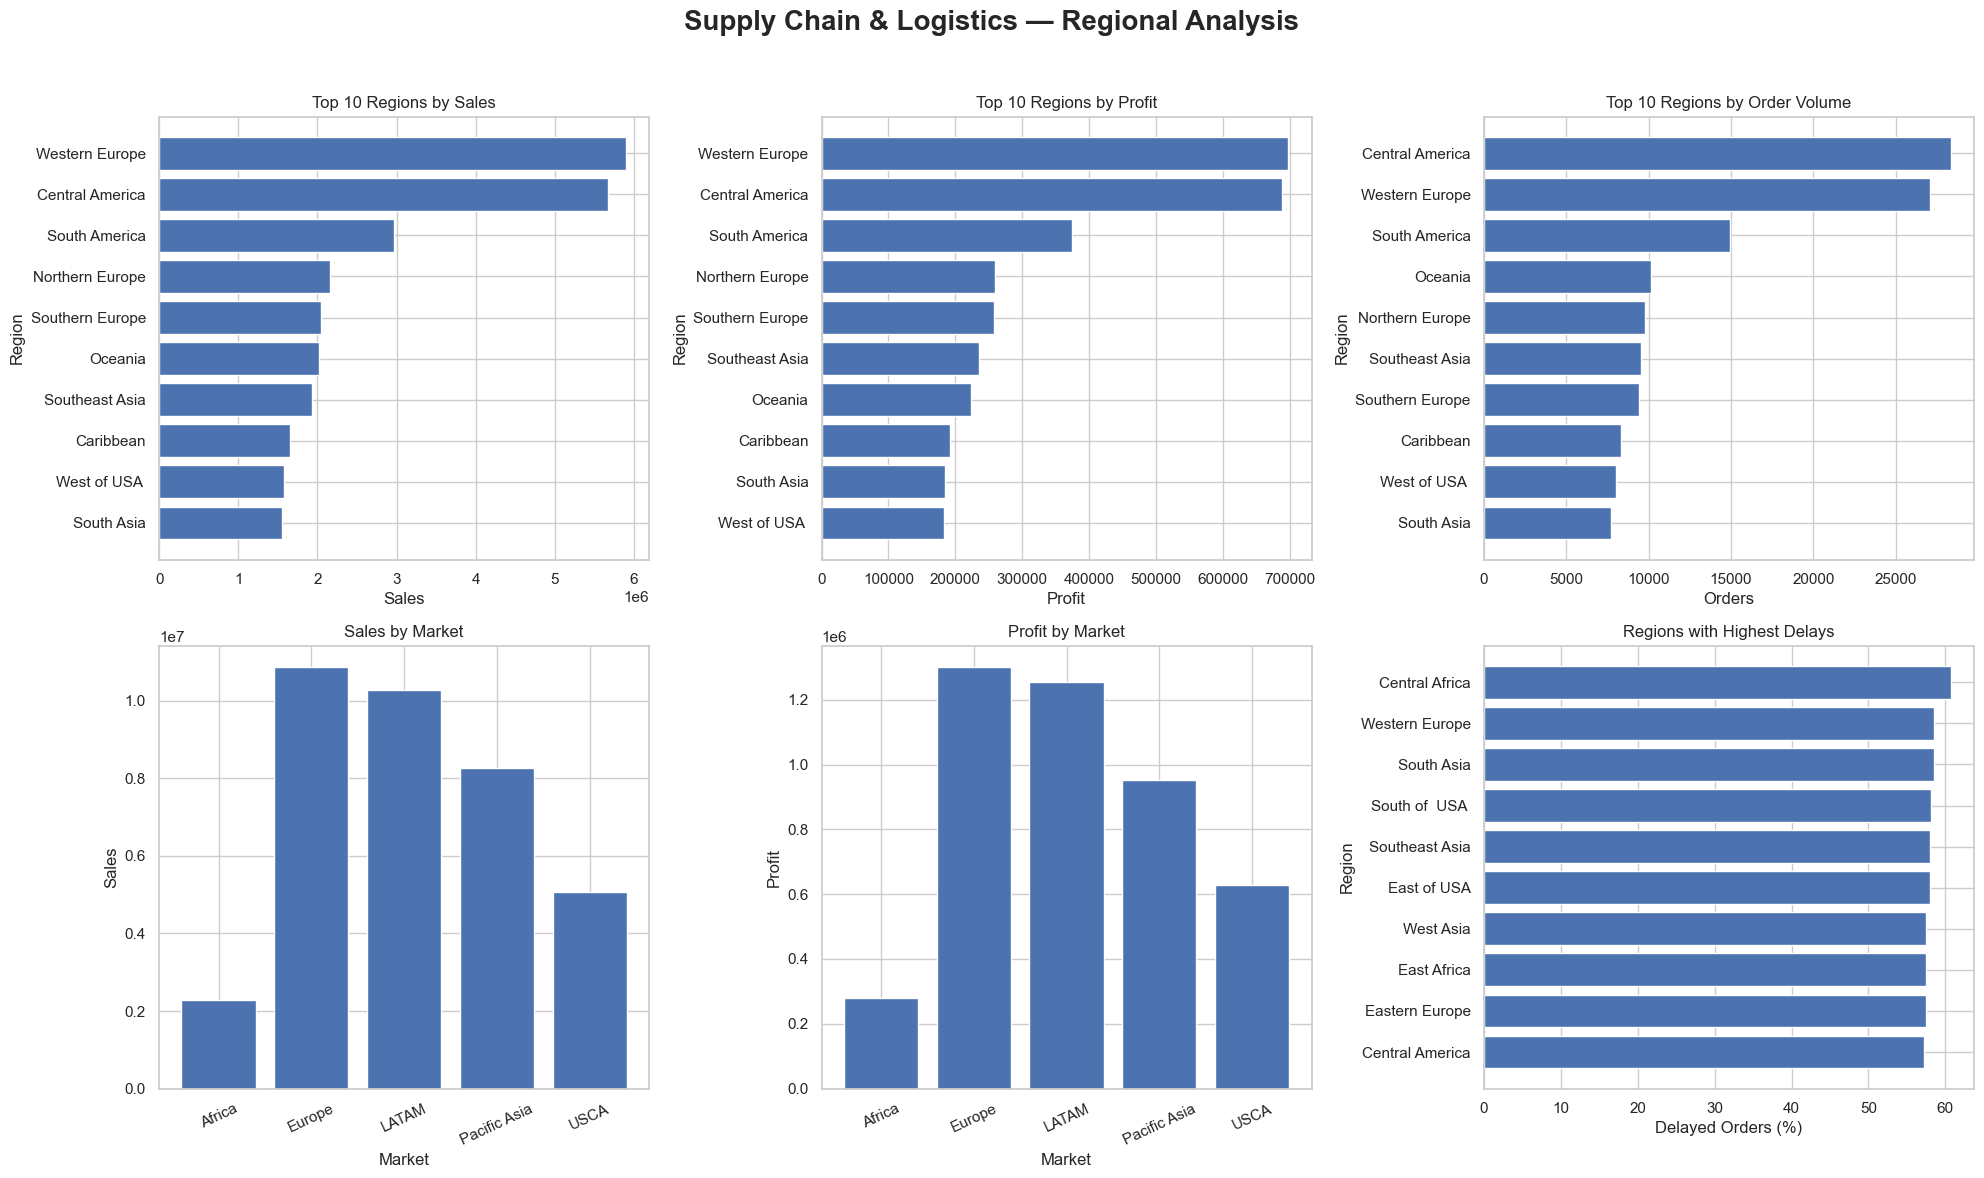

Saved successfully: ..\images\regional_analysis.png


In [132]:
# ============================================================
# 8.14 SAVE REGIONAL ANALYSIS IMAGE
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ------------------------------------------------------------
# 1. Top Regions by Sales
# ------------------------------------------------------------

sales_plot = top_regions_sales.sort_values("Sales")

axes[0, 0].barh(
    sales_plot["Order Region"],
    sales_plot["Sales"]
)

axes[0, 0].set_title("Top 10 Regions by Sales")
axes[0, 0].set_xlabel("Sales")
axes[0, 0].set_ylabel("Region")

# ------------------------------------------------------------
# 2. Top Regions by Profit
# ------------------------------------------------------------

profit_plot = top_regions_profit.sort_values("Profit")

axes[0, 1].barh(
    profit_plot["Order Region"],
    profit_plot["Profit"]
)

axes[0, 1].set_title("Top 10 Regions by Profit")
axes[0, 1].set_xlabel("Profit")
axes[0, 1].set_ylabel("Region")

# ------------------------------------------------------------
# 3. Top Regions by Orders
# ------------------------------------------------------------

orders_plot = top_regions_orders.sort_values("Orders")

axes[0, 2].barh(
    orders_plot["Order Region"],
    orders_plot["Orders"]
)

axes[0, 2].set_title("Top 10 Regions by Order Volume")
axes[0, 2].set_xlabel("Orders")
axes[0, 2].set_ylabel("Region")

# ------------------------------------------------------------
# 4. Market Sales
# ------------------------------------------------------------

axes[1, 0].bar(
    market_analysis["Market"],
    market_analysis["Sales"]
)

axes[1, 0].set_title("Sales by Market")
axes[1, 0].set_xlabel("Market")
axes[1, 0].set_ylabel("Sales")
axes[1, 0].tick_params(axis="x", rotation=25)

# ------------------------------------------------------------
# 5. Market Profit
# ------------------------------------------------------------

axes[1, 1].bar(
    market_analysis["Market"],
    market_analysis["Profit"]
)

axes[1, 1].set_title("Profit by Market")
axes[1, 1].set_xlabel("Market")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=25)

# ------------------------------------------------------------
# 6. Regional Delivery Delays
# ------------------------------------------------------------

delay_plot = regional_delivery.head(10).sort_values(
    "Delayed_%"
)

axes[1, 2].barh(
    delay_plot["Order Region"],
    delay_plot["Delayed_%"]
)

axes[1, 2].set_title("Regions with Highest Delays")
axes[1, 2].set_xlabel("Delayed Orders (%)")
axes[1, 2].set_ylabel("Region")

# ------------------------------------------------------------
# Main Title
# ------------------------------------------------------------

fig.suptitle(
    "Supply Chain & Logistics — Regional Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

regional_image_path = (
    IMAGES_PATH / "regional_analysis.png"
)

plt.savefig(
    regional_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved successfully: {regional_image_path}"
)

### Business Insights

The following insights were identified from the regional and geographic performance analysis:

- Regional analysis highlights differences in sales, profit, order volume, and overall business performance across geographic areas.
- High-performing regions contribute significantly to overall revenue and profitability and can be prioritized for continued business growth.
- Differences in regional profit margins indicate varying levels of profitability across geographic markets.
- Some regions show higher delivery delays, highlighting potential opportunities for logistics and distribution improvement.
- Comparing regional sales, profitability, and delivery performance helps identify areas for expansion, optimization, and operational improvement.

## 9. Executive Dashboard & Overall Summary

This section consolidates the major business, product, profitability, logistics, and regional performance indicators into an executive-level overview.

The dashboard provides a concise summary of overall sales, profit, orders, units sold, delivery performance, and key operational metrics.

In [133]:
# ============================================================
# 9.2 EXECUTIVE KPIs
# ============================================================

total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_orders = len(df_clean)
total_units = df_clean["Order Item Quantity"].sum()

profit_margin = (
    total_profit / total_sales * 100
    if total_sales != 0
    else 0
)

average_order_value = (
    total_sales / total_orders
    if total_orders != 0
    else 0
)

average_delivery_delay = df_clean[
    "Delivery_Delay_Days"
].mean()

delayed_order_percentage = (
    df_clean["Delivery_Performance"].eq("Delayed").mean()
    * 100
)

executive_kpis = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Total Units Sold",
        "Average Order Value",
        "Average Delivery Delay",
        "Delayed Order Percentage"
    ],
    "Value": [
        total_sales,
        total_profit,
        profit_margin,
        total_orders,
        total_units,
        average_order_value,
        average_delivery_delay,
        delayed_order_percentage
    ]
})

executive_kpis

,Metric,Value
0,Total Sales,3.678474e+07
1,Total Profit,4.418272e+06
2,Profit Margin,1.201116e+01
3,Total Orders,1.805190e+05
4,Total Units Sold,3.840790e+05
5,Average Order Value,2.037721e+02
6,Average Delivery Delay,5.658075e-01
7,Delayed Order Percentage,5.727929e+01


In [134]:
# ============================================================
# 9.3 EXECUTIVE SUMMARY
# ============================================================

print("============================================================")
print("SUPPLY CHAIN & LOGISTICS — EXECUTIVE SUMMARY")
print("============================================================")

print(f"Total Sales              : ${total_sales:,.2f}")
print(f"Total Profit             : ${total_profit:,.2f}")
print(f"Profit Margin            : {profit_margin:.2f}%")
print(f"Total Orders             : {total_orders:,}")
print(f"Total Units Sold         : {total_units:,}")
print(f"Average Order Value      : ${average_order_value:,.2f}")
print(f"Average Delivery Delay   : {average_delivery_delay:.2f} days")
print(f"Delayed Order Percentage : {delayed_order_percentage:.2f}%")

print("============================================================")

SUPPLY CHAIN & LOGISTICS — EXECUTIVE SUMMARY
Total Sales              : $36,784,735.01
Total Profit             : $4,418,272.19
Profit Margin            : 12.01%
Total Orders             : 180,519
Total Units Sold         : 384,079
Average Order Value      : $203.77
Average Delivery Delay   : 0.57 days
Delayed Order Percentage : 57.28%


In [135]:
# ============================================================
# 9.4 TOP BUSINESS PERFORMERS
# ============================================================

best_product = (
    product_analysis
    .sort_values("Sales", ascending=False)
    .iloc[0]
)

best_profit_product = (
    product_analysis
    .sort_values("Profit", ascending=False)
    .iloc[0]
)

best_region = (
    regional_analysis
    .sort_values("Sales", ascending=False)
    .iloc[0]
)

best_profit_region = (
    regional_analysis
    .sort_values("Profit", ascending=False)
    .iloc[0]
)

best_market = (
    market_analysis
    .sort_values("Sales", ascending=False)
    .iloc[0]
)

best_profit_market = (
    market_analysis
    .sort_values("Profit", ascending=False)
    .iloc[0]
)

print(f"Top Product by Sales   : {best_product['Product Name']}")
print(f"Top Product Sales      : ${best_product['Sales']:,.2f}")

print()

print(
    f"Top Product by Profit  : "
    f"{best_profit_product['Product Name']}"
)

print(
    f"Top Product Profit     : "
    f"${best_profit_product['Profit']:,.2f}"
)

print()

print(
    f"Top Region by Sales    : "
    f"{best_region['Order Region']}"
)

print(
    f"Top Region Sales       : "
    f"${best_region['Sales']:,.2f}"
)

print()

print(
    f"Top Region by Profit   : "
    f"{best_profit_region['Order Region']}"
)

print(
    f"Top Region Profit      : "
    f"${best_profit_region['Profit']:,.2f}"
)

print()

print(
    f"Top Market by Sales    : "
    f"{best_market['Market']}"
)

print(
    f"Top Market Sales       : "
    f"${best_market['Sales']:,.2f}"
)

print()

print(
    f"Top Market by Profit   : "
    f"{best_profit_market['Market']}"
)

print(
    f"Top Market Profit      : "
    f"${best_profit_market['Profit']:,.2f}"
)

Top Product by Sales   : Field & Stream Sportsman 16 Gun Fire Safe
Top Product Sales      : $6,929,653.69

Top Product by Profit  : Field & Stream Sportsman 16 Gun Fire Safe
Top Product Profit     : $841,601.94

Top Region by Sales    : Western Europe
Top Region Sales       : $5,894,380.77

Top Region by Profit   : Western Europe
Top Region Profit      : $697,490.65

Top Market by Sales    : Europe
Top Market Sales       : $10,872,396.80

Top Market by Profit   : Europe
Top Market Profit      : $1,301,774.24


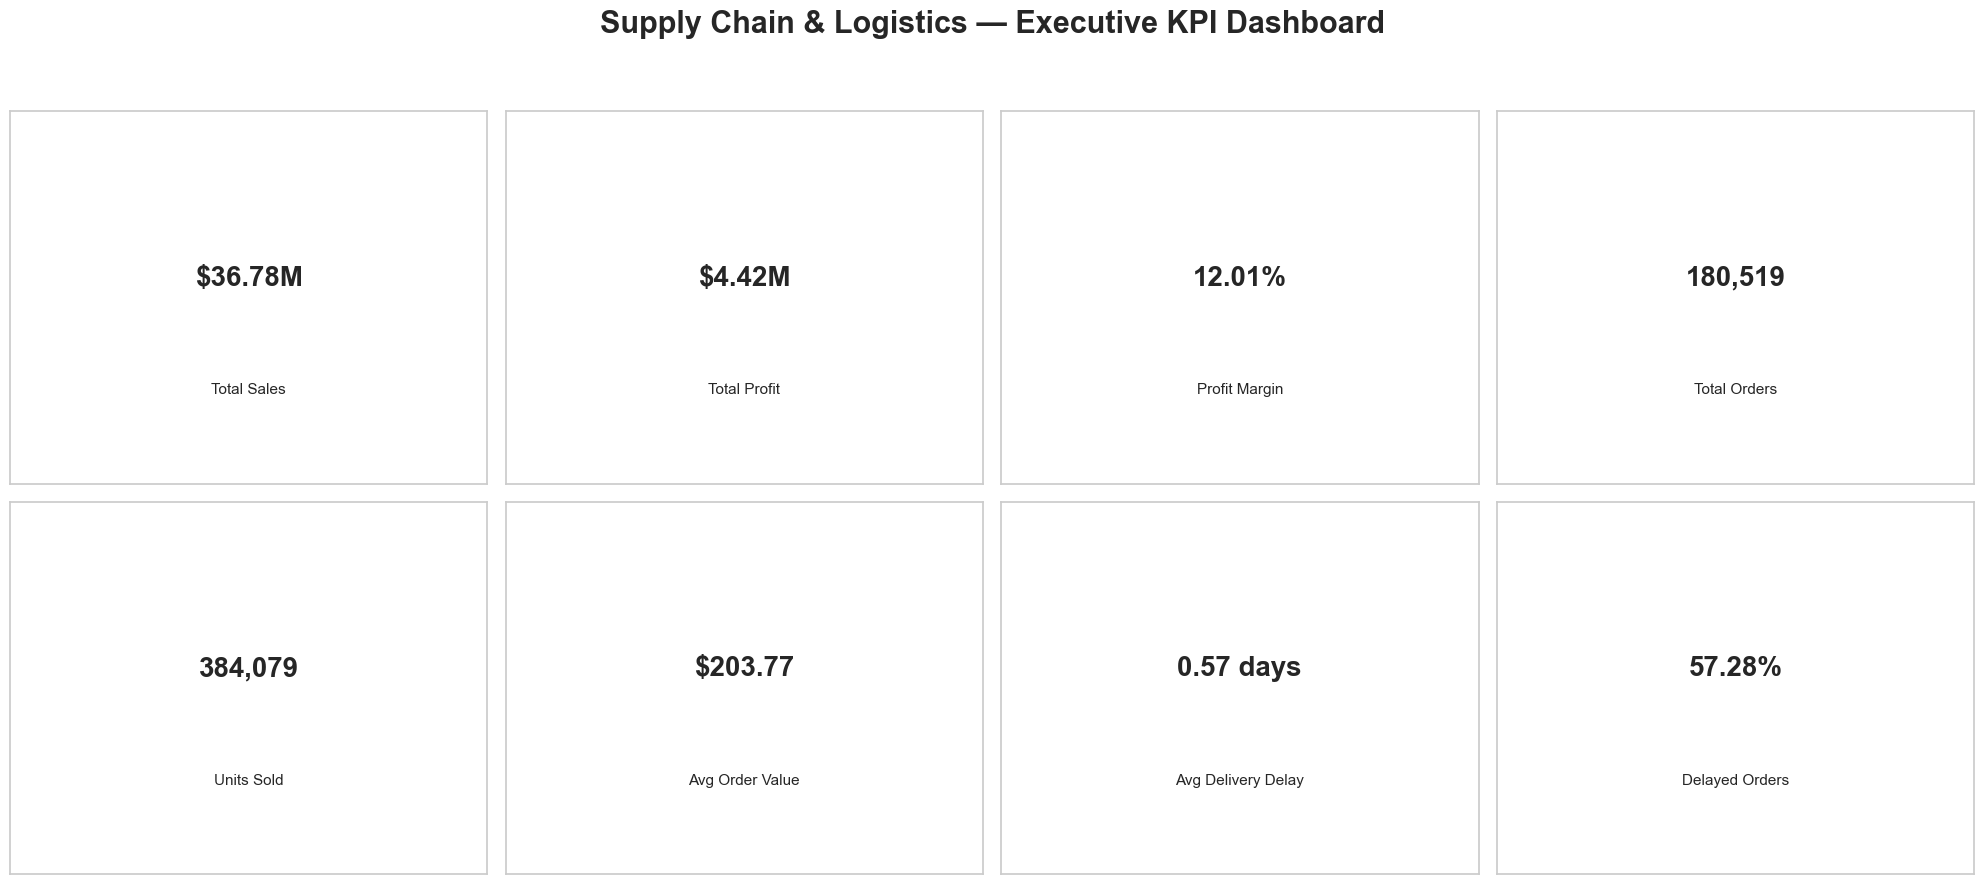

In [136]:
# ============================================================
# 9.5 EXECUTIVE KPI VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

kpi_data = [
    ("Total Sales", f"${total_sales/1e6:.2f}M"),
    ("Total Profit", f"${total_profit/1e6:.2f}M"),
    ("Profit Margin", f"{profit_margin:.2f}%"),
    ("Total Orders", f"{total_orders:,}"),
    ("Units Sold", f"{total_units:,}"),
    ("Avg Order Value", f"${average_order_value:.2f}"),
    ("Avg Delivery Delay", f"{average_delivery_delay:.2f} days"),
    ("Delayed Orders", f"{delayed_order_percentage:.2f}%")
]

for ax, (label, value) in zip(
    axes.flatten(),
    kpi_data
):
    ax.text(
        0.5,
        0.55,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.25,
        label,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Supply Chain & Logistics — Executive KPI Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.show()

In [137]:
# ============================================================
# 9.6 SALES & PROFIT BY MARKET
# ============================================================

fig = px.bar(
    market_analysis,
    x="Market",
    y=["Sales", "Profit"],
    barmode="group",
    title="Overall Sales and Profit by Market"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Amount"
)

fig.show()

In [138]:
# ============================================================
# 9.7 OVERALL DELIVERY PERFORMANCE
# ============================================================

fig = px.pie(
    delivery_performance,
    names="Delivery_Performance",
    values="Orders",
    title="Overall Delivery Performance"
)

fig.show()

In [139]:
# ============================================================
# 9.8 OVERALL PRODUCT PERFORMANCE
# ============================================================

fig = px.bar(
    performance_distribution,
    x="Performance",
    y="Products",
    text_auto=True,
    title="Overall Product Performance"
)

fig.update_layout(
    xaxis_title="Performance Classification",
    yaxis_title="Number of Products"
)

fig.show()

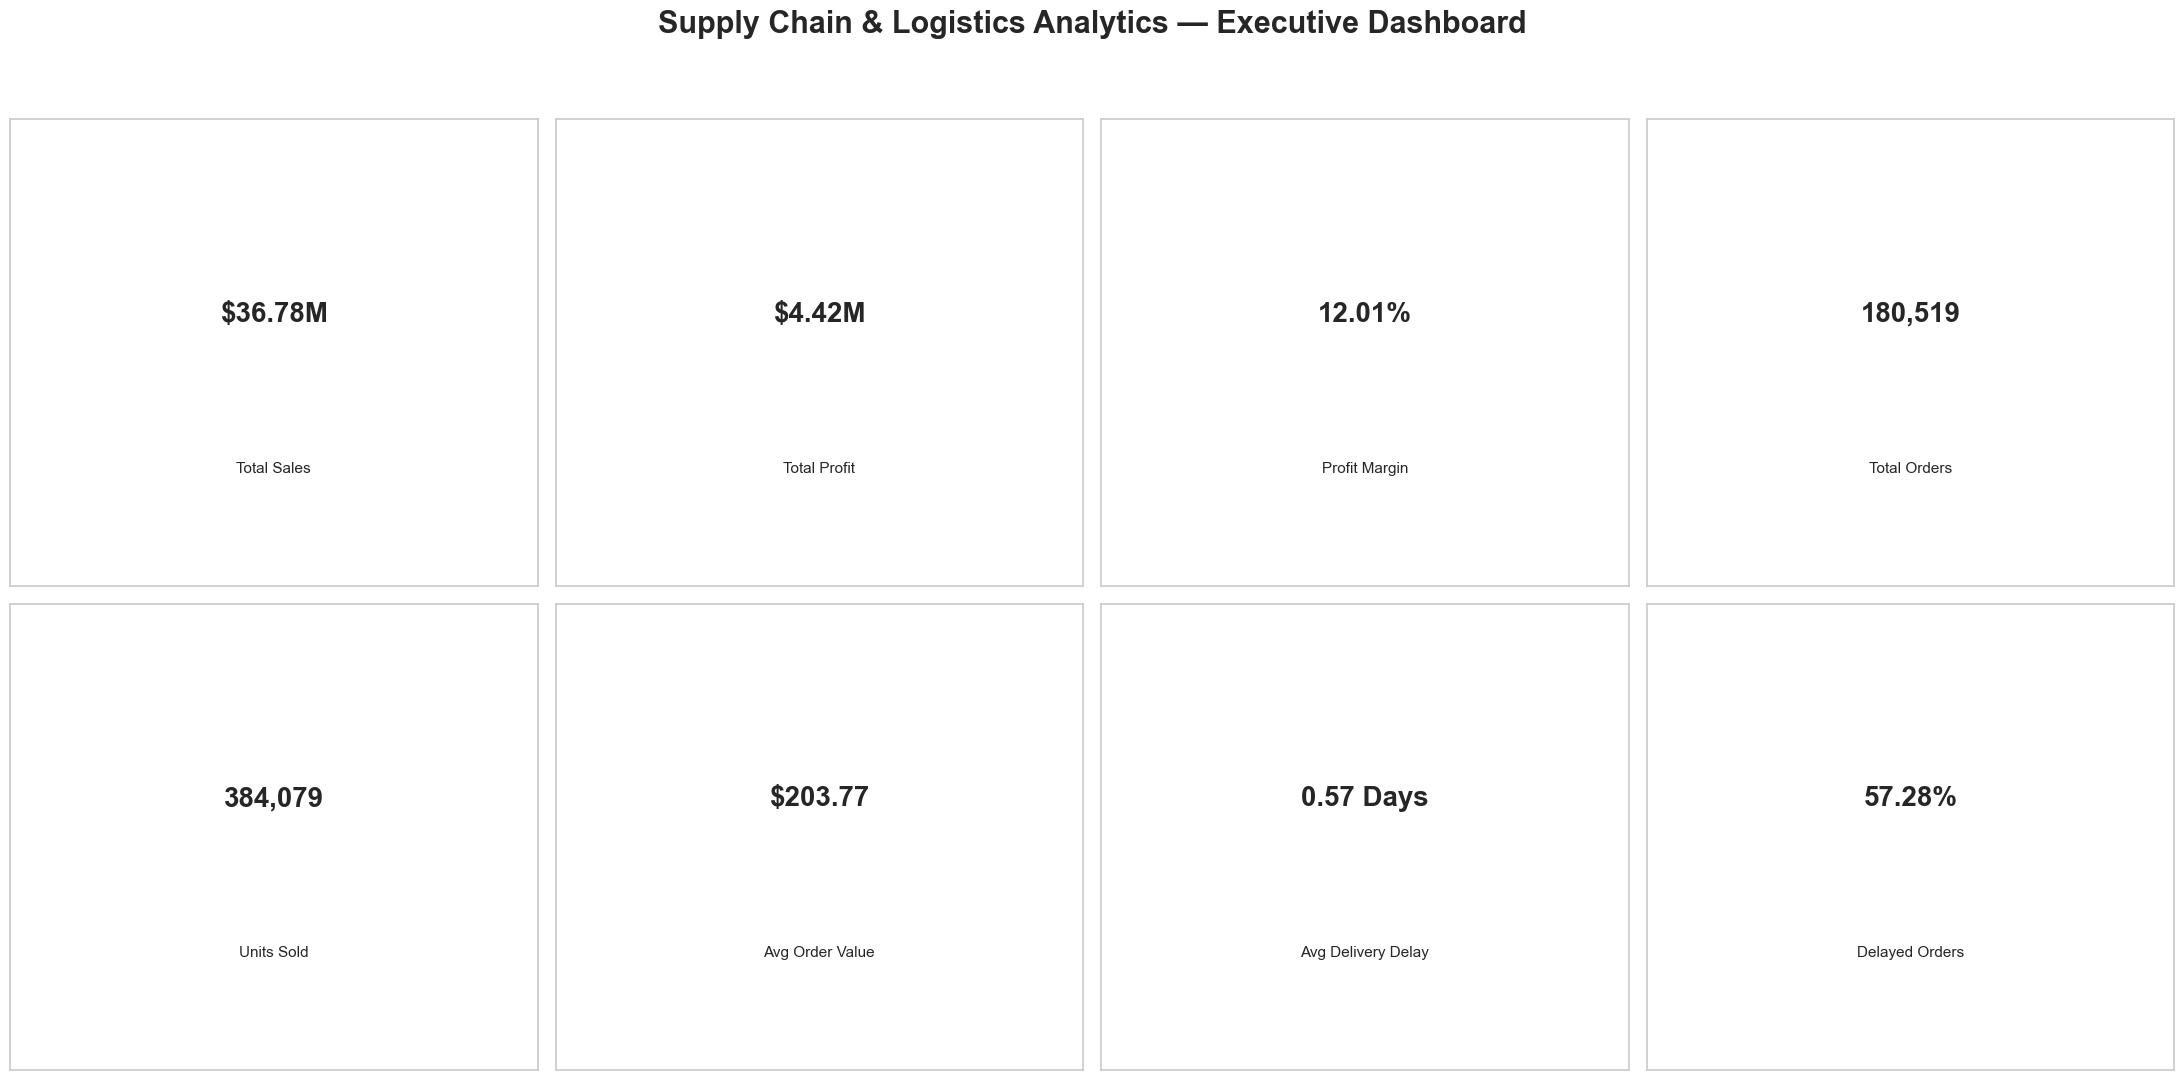

Saved successfully: ..\images\dashboard_overview.png


In [140]:
# ============================================================
# 9.9 SAVE DASHBOARD OVERVIEW
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 4, figsize=(22, 11))

# ------------------------------------------------------------
# KPI CARDS
# ------------------------------------------------------------

kpi_data = [
    ("Total Sales", f"${total_sales/1e6:.2f}M"),
    ("Total Profit", f"${total_profit/1e6:.2f}M"),
    ("Profit Margin", f"{profit_margin:.2f}%"),
    ("Total Orders", f"{total_orders:,}"),
    ("Units Sold", f"{total_units:,}"),
    ("Avg Order Value", f"${average_order_value:.2f}"),
    ("Avg Delivery Delay", f"{average_delivery_delay:.2f} Days"),
    ("Delayed Orders", f"{delayed_order_percentage:.2f}%")
]

for ax, (label, value) in zip(
    axes.flatten(),
    kpi_data
):
    ax.text(
        0.5,
        0.58,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.25,
        label,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Supply Chain & Logistics Analytics — Executive Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

dashboard_image_path = (
    IMAGES_PATH / "dashboard_overview.png"
)

plt.savefig(
    dashboard_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved successfully: {dashboard_image_path}"
)

### Overall Business Insights

The Supply Chain & Logistics Analytics project provides a consolidated view of sales, profitability, product performance, logistics efficiency, and regional performance.

Key areas identified through the analysis include:

- Overall sales and profitability provide a clear view of the business's financial performance and operational health.
- Product and category analysis identifies high-performing products as well as products requiring profitability and performance optimization.
- Logistics analysis highlights delivery performance, shipping efficiency, and areas where delays may require operational improvement.
- Regional and market analysis reveals differences in sales, profitability, order volume, and delivery performance across geographic areas.
- The combined analysis supports data-driven decisions related to product strategy, pricing, logistics optimization, regional growth, and overall business performance.

## Conclusion

The Supply Chain & Logistics Analytics project analyzed sales, profitability, product performance, logistics efficiency, and regional business performance using data-driven techniques.

The analysis identified key patterns across products, categories, markets, regions, shipping modes, and delivery performance. These insights can support better decisions related to pricing, product strategy, inventory planning, logistics optimization, and regional business growth.

Overall, the project demonstrates the use of Python, Pandas, NumPy, Matplotlib, Plotly, and exploratory data analysis techniques to transform raw supply chain data into meaningful business insights.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Plotly
- Jupyter Notebook
- Exploratory Data Analysis (EDA)
- Data Cleaning & Transformation
- Business Intelligence & Data Visualization

## Project Outputs

The analysis generates the following visualization assets:

- `dashboard_overview.png` — Executive-level business overview
- `sales_analysis.png` — Sales and revenue analysis
- `logistics_analysis.png` — Logistics and delivery performance
- `product_analysis.png` — Product and category performance
- `regional_analysis.png` — Regional and geographic performance